# JobFit: Evidence-Grounded Job Matching and Skill-Gap Analysis for Early-Career AI & Data Job Seekers

*Indonesia-first job matching that checks every requirement against real evidence from your CV.*

JobFit helps early-career AI and data job seekers decide which jobs to prioritize and why. It matches a CV against real job postings, checks each requirement (skills, seniority, location) against evidence from the CV, and explains what is matched, partial, or missing. It then highlights the skill gaps that matter most for the target role. Built Indonesia-first, covering local, regional, and remote roles.

| | |
| --- | --- |
| Notebook | Research for Checkpoint 1: dataset, data quality, feature transformation, and EDA of AI/ML/Data job postings |
| Project | Final Project Dibimbing DSML |
| Data | Snapshot `CP1_20260926`, job postings from JSearch (Google for Jobs), collected on 25 and 26 September 2026 |
| Author | Gidion Depari |

## About this notebook

### Goal

JobFit wants to help early-career job seekers find AI/ML/Data jobs that are **realistic to apply for**, and then explain why a job is a fit or not yet a fit. Before building the system, we first need to understand the data: how clean it is, what information is available, and what the job postings actually ask for.

This notebook answers four questions:

1. **Can the data be trusted?** (duplicates, completeness, sources, dates)
2. **What features can be built from the raw data?** (role, seniority, experience, location, skills, education)
3. **What is inside the job postings in this corpus?** (roles, experience requirements, skills, locations)
4. **What design decisions come from the data?**

Every step from raw data to insight runs in this notebook, and the notebook can be re-run from the start with the same results.

### Link to the Checkpoint 1 stages

| CP1 stage | Section in the notebook |
| --- | --- |
| 1. Dataset selection and exploration | 1.1 to 1.3 |
| 2. Data understanding and setting goals | 1.4 |
| 3. Data cleaning and missing values | 2 |
| 4. Data manipulation / feature transformation | 3 |
| 5. EDA: distributions and visualization | 4 |
| 6. EDA: insight and preprocessing documentation | 5 |
| 7. PPT and mentoring | outside the notebook, using the figures and summary from this notebook |

### Terms used often

| Term | Meaning |
| --- | --- |
| API slot | One search result from JSearch (an API result slot). The same job can appear in several slots. |
| Job (cluster) | A group of slots treated as the same job after dedup. There are 910, and this is still an estimate because dedup is still v0 (the 3 UNSURE pairs are flagged for re-check). |
| EDA candidate | A job with JD text of at least 700 characters that is not a generic application form. There are 632. In the code and chart titles they are called *auditable*. |
| Target role | AI/ML engineering, GenAI/LLM, data science, and software AI. Other roles are used as comparison roles. |
| Experience signal | A number of years of experience, or a phrase like *fresh graduate*, that the rules find in the JD text. It is not always a hard requirement. |
| UNKNOWN | The information was not found. In JobFit, UNKNOWN is never treated as a match. |

### How to read

Every step follows the same pattern so the flow connects:

- **Why:** the reason for this step.
- *(code and output)*
- **Result:** facts from the output, with the numbers and the data counts.
- **What it means:** the insight from the result and its impact on JobFit.
- **Note:** important limits so the result is not over-read (only when needed).
- **Next:** the next step and why that step needs to be checked.

### Summary of main findings

1. **Duplicates are removed, but job metadata is weak.** 1,314 API slots become 910 jobs and 632 EDA candidates. JD text is always there, but a structured posting date exists for only 30%, city for 20%, and salary for 3%. This means important information has to be taken from the JD text.
2. **The job title cannot be used to judge the level.** 128 of the 405 jobs with no level word in the title actually mention 3+ years of experience. On the other side, 37 of the 49 jobs within reach for beginners also do not write "junior" or "intern" in the title.
3. **There are few jobs for beginners.** Of 175 target jobs in Indonesia, only 49 (28%) have an entry-level signal or at most 2 years. 69 (39%) mention 3+ years, and 57 (33%) do not mention experience at all.
4. **The word "AI" in a title can be misleading.** 49 of the 463 titles that mention AI are not target roles, for example content creator, consultant, or QA.
5. **Required skills differ by role, and GenAI skills come as a bundle.** Statistics is mentioned in 78% of data science JDs but only 2% of GenAI JDs. JDs that mention LLM also mention RAG (53% vs 4%) and AI agents (58% vs 12%) much more often.
6. **Indonesia differs from other countries in some skills.** After role and JD length are balanced, Indonesian JDs mention SQL more often (+8.8 points) and machine learning less often (−23.7 points). The gap in GenAI skills almost disappears.
7. **Locations are concentrated, and work mode is rarely written.** 79.6% of Indonesian candidates are in Jabodetabek (Greater Jakarta), and the work mode is unclear in 76% of Indonesian JDs.

All labels above are rule-based v0 labels (baseline). Their accuracy will be measured against the CP2 gold set.

### Table of contents

0. Setup
1. Data and its origin (including 1.4 Data understanding and goals)
2. Data quality and cleaning
3. Feature transformation
4. Exploratory Data Analysis (EDA)
5. Insight, design decisions, and next steps

## 0. Setup

**Why:** all cleaning and transformation rules are written in the `src/jobfit/jobs/` modules, not directly in the notebook. There are two reasons. First, the same rules will be reused by the application pipeline (FastAPI), so research results and application results will not differ. Second, rules in modules can be tested with unit tests (`tests/test_jobs_rules.py`). The job of this notebook is to run those rules, check the results, and explain what they mean.

In [1]:
import sys, json, hashlib, re
from collections import Counter
from pathlib import Path

# Find the project root (the folder with src/jobfit) so project imports work
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "jobfit").exists())
sys.path.insert(0, str(ROOT / "src"))

# Analysis libraries, plus the shared chart style used by every figure
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from jobfit.viz.style import apply_style, barh, save, SERIES, NEUTRAL, INK_2, MUTED, SEQ

# Apply the chart style and table display options; figures go to reports/figures/cp1
apply_style()
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)
FIG = ROOT / "reports/figures/cp1"
print("Project:", ROOT.name)

Project: run


## 1. Data and its origin

### 1.1 Where does this data come from?

Job postings were collected through the **JSearch API (OpenWeb Ninja)**, which pulls job postings from Google for Jobs. With one API, we get job postings from many publishers (LinkedIn, Glints, Indeed, and others), together with their JD text. Collection was done in stages: a benchmark, a pilot, then batch 02 to 07, and every batch was audited. The details are in `docs/checkpoint_1/supporting/CP1_Dataset_Inventory.md` and `evidence/checkpoint_1/corpus_collection/`.

The first target was 1,000 jobs, but collection stopped early. In the last batch, most results from the Indonesian queries we tested were jobs we already had, so adding more queries only added cost without many new jobs. This shortfall is reported as it is, not forced.

Things to keep in mind before reading the numbers:

- This data is a **query-based sample**. We chose the keywords and cities, so the results describe the JobFit corpus, not a random sample of the whole Indonesian job market.
- Jobs were collected from three directions: **Indonesia**, **foreign** (Singapore, Kuala Lumpur, Manila, and the US as comparison), and **remote**. After the location was checked against its evidence, the EDA uses four groups: Indonesia, foreign, remote, and **UNKNOWN** (country not known).
- Remote jobs are not yet verified as open to applicants from Indonesia.

### 1.2 Snapshot integrity check

**Why:** the raw data is frozen, and the SHA-256 hash of every file is recorded in `SNAPSHOT_MANIFEST.json`. A hash is like a fingerprint of a file. If the file content changes even a little, the hash changes too. We check it again to make sure every number in this notebook is computed from the same data that was audited during collection, not from a file that changed silently.

In [2]:
# Offline audit helpers: snapshot check, region label, and skill comparisons
from jobfit.jobs.research import verify_snapshot, analysis_geo, standardized_skill_comparison, skill_counts
# Step 1: check the SHA-256 hashes of the raw and frozen derived files
SNAPSHOT = ROOT / "data/interim/snapshots/CP1_20260926"
input_verification = verify_snapshot(ROOT)
# Step 2: load the snapshot records (one row per API slot) and the manifest
records = pd.read_json(SNAPSHOT / "jsearch_records.jsonl", lines=True, convert_dates=False)
manifest = json.loads((SNAPSHOT / "SNAPSHOT_MANIFEST.json").read_text(encoding="utf-8"))
print(input_verification["raw_inputs_verified"], "raw files and", input_verification["frozen_derived_inputs_verified"], "frozen derived files: hashes match")
# Sanity checks: unique record IDs and exactly one canonical record per cluster
assert records.record_id.is_unique
assert records.groupby("final_cluster_id").is_canonical.sum().eq(1).all()
print(f"Records (API slots): {len(records):,}")
records.head(3)[["record_id", "batch", "query", "company", "title", "source_platform", "jd_quality"]]


460 raw files and 5 frozen derived files: hashes match
Records (API slots): 1,314


,record_id,batch,query,company,title,source_platform,jd_quality
0,CP1_JSearch_JS02_AIEngineer_ID_id_Screenshot#1,BENCHMARK,AI Engineer in Indonesia,PT StoryG Jaya Indonesia,Backend Engineer (AI Engineer),Glints,full
1,CP1_JSearch_JS02_AIEngineer_ID_id_Screenshot#2,BENCHMARK,AI Engineer in Indonesia,CODE.ID,AI Developer Fluent English,LinkedIn,full
2,CP1_JSearch_JS02_AIEngineer_ID_id_Screenshot#3,BENCHMARK,AI Engineer in Indonesia,Dot Indonesia,Agentic AI Developer,Glints,full


**Result:**

- All **460 raw files** and **5 frozen derived files** match the hashes in the manifest.
- There are **1,314 records**, and each record is one API slot.

**What it means:** the numbers in this notebook are computed from exactly the same data that was audited. If the analysis results change one day, we know the cause is a rule change, not data that changed silently.

**Note:** a hash only guarantees that the file is the same, not that its content is correct. Duplicates, summary JDs, or wrong locations still have to be checked in the next steps.

**Next:** one job can appear in several queries and publishers at once. So we first need to know how many jobs are really different.

### 1.3 Funnel: from API slots to final jobs

**Why:** the unit of analysis in JobFit is the **job**, not the API slot. If one job appears 5 times and is counted 5 times, its skills are also counted 5 times, and the EDA results lean toward the jobs that appear most often. Dedup is done in two stages:

1. **Automatic**, with keys that must be identical: job ID, URL, JD content hash, and the combination of employer, title, and location.
2. **Review of 40 pairs** that are similar but not identical. Each pair was reviewed against the text evidence. This step is still v0, and pairs marked UNSURE are flagged for re-check (`data/interim/dedup_decisions.csv`).

,stage,n
0,Raw API slots,1314
1,Exact-key clusters,937
2,Final clusters (estimated jobs),910
3,EDA candidates (JD length + source filter),632


Duplicate review decisions: {'SAME': 29, 'DIFFERENT': 8, 'UNSURE': 3}


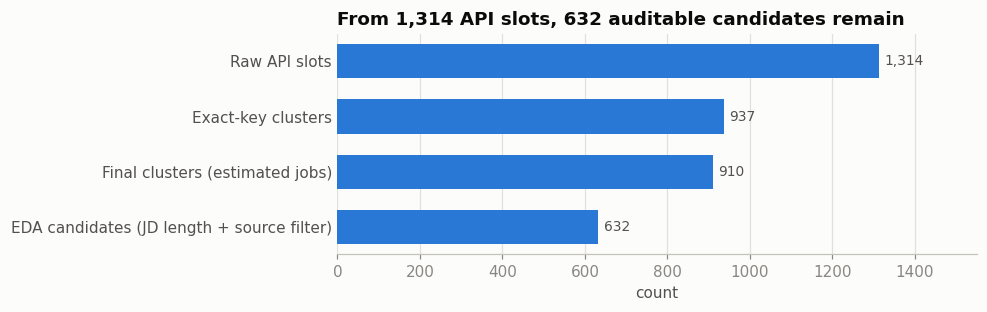

In [3]:
# Keep one canonical record per final cluster; auditable = full JD and no generic form
canon = records[records.is_canonical].copy()
canon["is_auditable"] = (canon.jd_quality == "full") & ~canon.provenance_flags.apply(lambda f: "generic_external_form" in f)
# Pair decisions from the dedup review (SAME / DIFFERENT / UNSURE)
decisions = pd.read_csv(SNAPSHOT / "dedup_decisions.csv")

# Funnel: rows left after each step, from raw API slots to EDA candidates
funnel = pd.DataFrame([
    ("Raw API slots", len(records)),
    ("Exact-key clusters", records.cluster_id.nunique()),
    ("Final clusters (estimated jobs)", records.final_cluster_id.nunique()),
    ("EDA candidates (JD length + source filter)", int(canon.is_auditable.sum())),
], columns=["stage", "n"])
display(funnel)
print("Duplicate review decisions:", decisions.decision.value_counts().to_dict())

# Figure 1: the funnel as horizontal bars
fig, ax = plt.subplots(figsize=(7.5, 2.6))
barh(ax, funnel.stage.tolist(), funnel.n.tolist())
ax.set_title("From 1,314 API slots, 632 auditable candidates remain")
ax.set_xlabel("count")
save(fig, FIG / "fig01_funnel.png"); plt.show()

**Result:**

- 1,314 API slots become **937 clusters** with identical keys, and then **910 jobs** after the similar pairs are reviewed (29 pairs judged SAME, 8 DIFFERENT, and 3 UNSURE).
- Of the 910 jobs, **632 pass as EDA candidates**: their JD text is at least 700 characters and they are not a generic application form.

**What it means:**

- About **3 in 10 slots are duplicates** (1,314 become 910). Without dedup, jobs that show up in many queries would look more "important" than they really are.
- The skill analysis only uses the 632 EDA candidates, because short JDs are usually just summaries without a requirement list. As a result, the skill findings apply to these 632 jobs, not automatically to all 910. The other 278 jobs are still kept so the reason they were not used can be audited.

**Note:** the labels `full` and `auditable` only mean "the text is long enough and the source has no problem". They do not guarantee that the JD contains all requirements or that the job is still open.

**Next:** before cleaning the data, we first agree on what one row of data is, what it contains, and which questions we want to answer with it.

### 1.4 Data understanding and setting goals

**Why:** without clear definitions, numbers get mixed up easily. For example, API slots get counted as jobs, or a percentage of 910 jobs is compared with a percentage of 632 EDA candidates. This section sets the data unit, its content, the groups being compared, and the questions to answer.

**Data unit**

| Unit | Count | Used for |
| --- | ---: | --- |
| API slot | 1,314 | collection audit and dedup |
| Job (final cluster) | 910 | clean data, data quality, language, and dates |
| EDA candidate | 632 | feature transformation, and analysis of role, experience, skills, and location |

**What one job contains**

Every job has three kinds of information:

1. **Identity and source:** employer, title, publisher, apply URL, and retrieval time.
2. **Structured metadata from the provider:** country, city, posting date, employment type, and salary. Section 2.1 shows these fields are often empty.
3. **JD text:** the main source of requirements, such as skills, experience, education, and work location.

The features JobFit needs most (role family, experience requirement, and skills) are **not available as columns**. All of them have to be built from the title and the JD text in section 3.

**Goals used**

The product goals come from PRE-Checkpoint 0 and are not changed here. Users want to be shown the jobs that fit their profile best, told what is missing, and helped to improve their CV without making up experience. The main pain from the pilot interviews is that a title that looks relevant turns out not to fit after the requirements are read, and the experience requirement is often the blocker.

In CP1, those goals are turned into questions that the data can answer:

| Research question | Answered in |
| --- | --- |
| Is the job title enough to judge role and seniority? | 3.2, 3.3, 4.1, 4.3 |
| How many Indonesian target jobs are within reach for beginners, based on the experience signal? | 4.2, 4.9 |
| Which skills are mentioned in JDs, and do they differ by role and by region? | 4.4 to 4.7 |
| How complete are location, work mode, and date for use as filters? | 2.1, 2.6, 3.4, 4.8 |

**What this data can and cannot answer yet**

| Can answer | Cannot answer yet |
| --- | --- |
| Which requirements are mentioned in JDs and how often | How well a CV fits a job, because there are no CVs or fit labels yet |
| Data problems the pipeline must handle (duplicates, empty fields, location) | Whether an experience number is required or only preferred, because there are no gold labels yet (planned for CP2) |
| Hard examples for the CP2 evaluation (misleading titles, jobs that are too senior) | The size of the national job market or trends over time, because the sample is query-based and covers only two days |
| Differences in skill patterns between roles and regions in the corpus | Salary (only 2-3% filled), whether a job is still active, and whether a remote job can really be applied to from Indonesia |

**Next:** now that the unit and goals are clear, we check data quality, starting with the completeness of each field.

## 2. Data quality and cleaning

Three principles hold in this section:

- **UNKNOWN ≠ match.** An empty value stays empty and is not filled with a guess. If empty data were treated as a match, JobFit could recommend a job that actually asks for 5 years of experience.
- **`posted_at` is never filled with the retrieval time.** This is the mistake we saw in JobSentinel, where a 3-week-old job was shown as "0 days ago".
- **Raw data is not changed.** Cleaning results are stored in new columns, together with the rules that were applied, so every change can be traced.

### 2.1 Field completeness

**Why:** JobFit features depend on certain fields. The location filter needs country and city, freshness needs the posting date, and the preference layer needs employment type and salary. We check which fields can be used directly and which have to be taken from the text.

,field,complete_canonical_%,complete_auditable_%
0,employer,100.0,100.0
1,title,100.0,100.0
2,JD text,100.0,100.0
3,apply URL,100.0,100.0
4,location text,99.3,99.1
5,employment type,97.8,96.8
6,relative posting text,72.5,63.9
7,structured country,48.0,44.8
8,structured posted_at,30.2,30.2
9,structured city,25.3,20.4


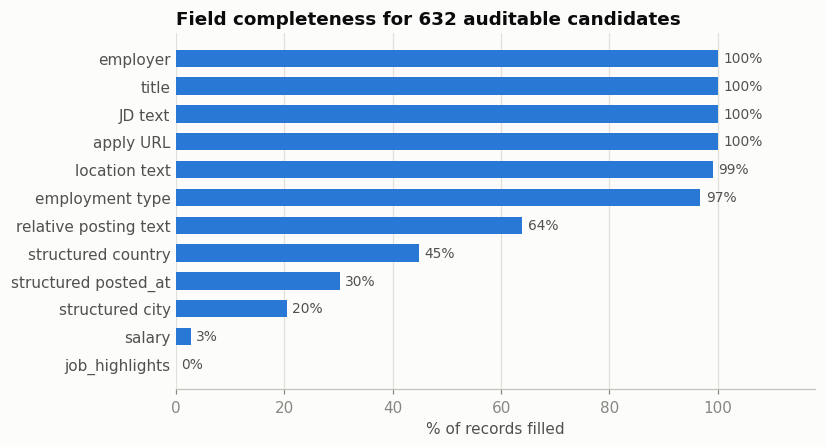

In [4]:
# Share of rows with a real value; empty strings/lists/dicts and NaN count as missing
def present(col, df):
    s = df[col]
    if col == "highlights":
        return s.apply(lambda d: bool(d)).mean()
    return s.apply(lambda v: v not in (None, "", [], {}) and not (isinstance(v, float) and pd.isna(v))).mean()

# Raw column name -> readable label used in the table and the chart
fields = {"company": "employer", "title": "title", "description": "JD text", "apply_url": "apply URL",
          "location_raw": "location text", "employment_type": "employment type", "provider_posted_text": "relative posting text",
          "country": "structured country", "posted_at": "structured posted_at", "city": "structured city",
          "highlights": "job_highlights"}
# Completeness for all canonical jobs vs the auditable subset; salary uses its own flag
aud = canon[canon.is_auditable]
completeness = pd.DataFrame({
    "field": list(fields.values()),
    "complete_canonical_%": [round(100 * present(c, canon), 1) for c in fields],
    "complete_auditable_%": [round(100 * present(c, aud), 1) for c in fields],
})
completeness.loc[len(completeness)] = ["salary", round(100 * canon.salary_present.mean(), 1), round(100 * aud.salary_present.mean(), 1)]
completeness = completeness.sort_values("complete_auditable_%", ascending=False).reset_index(drop=True)
display(completeness)

# Figure 2: completeness of each field among the auditable candidates
fig, ax = plt.subplots(figsize=(7.5, 4.2))
barh(ax, completeness.field.tolist(), completeness["complete_auditable_%"].tolist(), fmt="{:.0f}%")
ax.set_title("Field completeness for 632 auditable candidates")
ax.set_xlabel("% of records filled"); ax.set_xlim(0, 118)
save(fig, FIG / "fig02_field_completeness.png"); plt.show()

**Result:**

- **Always filled (100%):** employer, title, JD text, and apply URL. Location text is also almost always there (99.1%), and so is employment type (96.8%).
- **Often empty:** relative posting text is filled for 63.9%, country 44.8%, posted_at 30.2%, city 20.4%, salary 2.7%, and `job_highlights` 0%.

**What it means:**

- The information JobFit needs is actually there, but most of it is stored in **text**, not in structured columns. For example, city is filled for only 20%, while location text is filled for 99%. So location has to be read from the location text, and requirements have to be extracted from the JD text. This is the main reason JobFit needs an extraction step: rules in CP1, then a comparison with an LLM in CP2.
- **Filled does not mean correct.** Apply URL is 100% filled, but it is not always the official company link, and the job may not be open anymore.
- **Salary is not analyzed and not filled with a guess** (for example the average). Filling empty data does make the data look complete, but it adds information the source never gave. For JobFit, it is safer to show "not stated".

**Next:** JD text is the main source, so we check whether the text is really complete or only a summary.

### 2.2 JD text quality

**Why:** a JD that is too short is usually only a summary with no requirement list, so it cannot be used for skill extraction or for matching with a CV. A length threshold is used as a first filter (recorded in the data contract): `full` is at least 700 characters, `summary_only` is 200 to 699 characters, and `insufficient` is under 200 characters.

,jobs
jd_quality,
full,667
summary_only,236
insufficient,7


Publishers with the most summary JDs:


,summary_only
source_platform,
JobLeads,127
Jobrapido.com,29
Trabajo.org,26
Jooble,21
BeBee,6
Loker.id,4


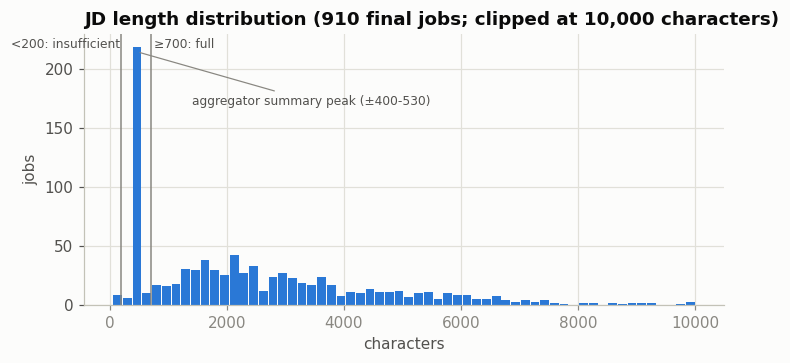

In [5]:
# JD quality labels for the 910 final jobs, and the publishers behind most summaries
display(canon.jd_quality.value_counts().rename("jobs").to_frame())
print("Publishers with the most summary JDs:")
display(canon[canon.jd_quality == "summary_only"].source_platform.value_counts().head(6).to_frame("summary_only"))

# Figure 3: JD length histogram with the 200 and 700 character thresholds
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(canon.description_length.clip(upper=10000), bins=60, color=SERIES[0], rwidth=0.9)
ymax = ax.get_ylim()[1]
ax.axvline(200, color=MUTED, linewidth=1); ax.axvline(700, color=MUTED, linewidth=1)
ax.text(180, ymax * 0.95, "<200: insufficient", color=INK_2, fontsize=8, ha="right")
ax.text(760, ymax * 0.95, "≥700: full", color=INK_2, fontsize=8, ha="left")
# Point at the aggregator summary peak around 400-530 characters
ax.annotate("aggregator summary peak (±400-530)", xy=(470, 215), xytext=(1400, 170), color=INK_2, fontsize=8,
            arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))
ax.set_title("JD length distribution (910 final jobs; clipped at 10,000 characters)")
ax.set_xlabel("characters"); ax.set_ylabel("jobs")
save(fig, FIG / "fig03_jd_length.png"); plt.show()

**Result:**

- 667 jobs are `full`, 236 are `summary_only`, and 7 are `insufficient`.
- The chart shows a **sharp peak at around 400 to 530 characters**.
- Most summary JDs come from JobLeads (127 of 236), then Jobrapido (29), Trabajo.org (26), and Jooble (21).

**What it means:** that peak is not a natural JD pattern. It is the summary format of aggregators that cut the original description. If summary JDs were counted, a skill would look rarer than it really is, only because the text was cut. That is why the skill analysis uses JDs of at least 700 characters. Of the 667 `full` JDs, 35 are removed because they use a generic application form (discussed in 2.3), which leaves 632 EDA candidates.

**Note:** the 700-character threshold is a practical rule for consistency, not an exact quality boundary. A 701-character JD is not automatically more complete than a 699-character JD. The content of each JD is still checked when the gold set (manually labeled evaluation set) is built.

**Next:** we check how often one job appears repeatedly and how trustworthy its source is.

### 2.3 Duplicates and job sources

**Why:** if one job appears 5 times, its skills are counted 5 times. Also, apply links from aggregators or job blogs need to be flagged so they are not shown to users as the official company link.

In [6]:
# How often one job repeats across API slots and across publishers
cluster_size = records.groupby("final_cluster_id").size()
pubs_per_cluster = records.groupby("final_cluster_id").source_platform.nunique()
display(pd.DataFrame({
    "metric": ["Jobs that appear >1 time", "Average slots per job", "Max slots per job", "Jobs that appear on >1 publisher"],
    "value": [str(int((cluster_size > 1).sum())), f"{cluster_size.mean():.2f}", str(int(cluster_size.max())), str(int((pubs_per_cluster > 1).sum()))],
}))
# Provenance flags on canonical jobs, then the outcome of the pair review
display(pd.Series(Counter(f for fl in canon.provenance_flags for f in fl), name="canonical jobs").to_frame())
display(decisions.decision.value_counts().to_frame("reviewed pairs"))

,metric,value
0,Jobs that appear >1 time,216
1,Average slots per job,1.44
2,Max slots per job,13
3,Jobs that appear on >1 publisher,39


,canonical jobs
apply_not_direct_per_provider,910
low_provenance_publisher,27
generic_external_form,35


,reviewed pairs
decision,
SAME,29
DIFFERENT,8
UNSURE,3


**Result:**

- **216 jobs appear more than once**, with an average of 1.44 slots per job and at most 13 times. 39 jobs appear on more than one publisher.
- The provider marks **all 910 jobs** as having an indirect apply link (`apply_not_direct_per_provider`), including official career pages such as Grab Careers. So this flag cannot be used to tell official links from aggregators.
- 27 jobs come from publishers with unclear sources (`low_provenance_publisher`) and are flagged. 35 jobs use a **generic application form from a job blog**, and these 35 are removed from the EDA candidates.
- Duplicate review: 29 SAME, 8 DIFFERENT, and 3 UNSURE.

**What it means:**

- Duplicates do not only double the count. They also double the same skills, experience, and location. Without dedup, a job that appears 13 times would pull the EDA results toward it.
- On the other side, dedup that is too aggressive can merge two different positions that use a similar JD template. That is why every decision is stored with its reason, and the 3 UNSURE pairs are flagged for re-check.
- For JobFit, the job source needs to be shown to users as it is, and links from job blogs must not be presented as official company links.

**Next:** now that we know which jobs are used, we clean their JD text.

### 2.4 Cleaning the JD text

**Why:** the JD text will be read by models (extraction and embedding) and shown to users. Noise like aggregator tracking codes is useless for the model, and recruiter emails or phone numbers should not appear in a public demo.

Rules `cleaning_v0.1_audited`: decode HTML entities, remove HTML tags, remove tracking codes (for example `#J-18808-Ljbffr`), remove job-blog template intros, **mask emails and Indonesian mobile number patterns**, remove markdown headers, and tidy up spaces. Bullets and line breaks are kept.

In [7]:
from jobfit.jobs.cleaning import clean_description, detect_language, derive_posted_at, normalize_employment_type, CLEANING_VERSION

# Apply the cleaning rules; the raw description is kept and results go to new columns
cleaned = canon.description.apply(clean_description)
canon["description_clean"] = cleaned.str[0]
canon["cleaning_rules"] = cleaned.str[1]
canon["clean_length"] = canon.description_clean.str.len()
# How many jobs each rule touched (one job can hit several rules)
display(pd.Series(Counter(r for rules in canon.cleaning_rules for r in rules), name="jobs").sort_values(ascending=False).to_frame())

# Before/after example: a job with a tracking code but no email, so nothing private prints
ex = canon[canon.cleaning_rules.apply(lambda r: "aggregator_tracking_code" in r and "email_masked" not in r)].iloc[0]
print("BEFORE (end of text):", repr(ex.description[-120:]))
print("AFTER (end of text):", repr(ex.description_clean[-120:]))

,jobs
aggregator_tracking_code,75
nonbreaking_spaces,69
markdown_headers,31
email_masked,20
job_blog_intro,3
html_entities,2
phone_masked,1


BEFORE (end of text): ' English fluency is required with Mandarin/Korean advantageous. Dormitory, meals, and parking provided.\n\n#J-18808-Ljbffr'
AFTER (end of text): 'rk are essential; English fluency is required with Mandarin/Korean advantageous. Dormitory, meals, and parking provided.'


**Result:**

- The rules applied most often: aggregator tracking code (75 jobs), non-standard spaces (69), markdown headers (31), masked emails (20), blog intro (3), HTML entities (2), and masked phone number (1). One job can hit several rules.
- Example in the output: the code `#J-18808-Ljbffr` at the end of the text is gone, while the sentences stay the same.
- The total text length dropped by only 2,444 characters out of about 2.28 million characters, or about 0.1%.

**What it means:** cleaning is kept light on purpose. Only noise that is surely useless is removed. Bullets, sentence order, and words like "preferred" or "diutamakan" (Indonesian for "preferred") are kept, because those words are needed later to tell required items from optional ones. If cleaning were too aggressive, important clues for the extractor could be lost.

**Note:** masking here covers only emails and Indonesian mobile number patterns. It is not full anonymization of personal data. The original text is still stored in the snapshot.

**Next:** because jobs come from Indonesia and abroad, we check the JD language. The language decides whether the skill dictionary and the extractor need to support two languages.

### 2.5 JD language

**Why:** if many JDs are in Indonesian, the English skill dictionary and the extraction prompt have to be tested in both languages.

In [8]:
# Detect the JD language from common function words (a heuristic, not a trained model)
canon["jd_language"] = canon.description_clean.apply(detect_language)
# Rows: collection group; columns: detected language
pd.crosstab(canon.geo_stratum, canon.jd_language, margins=True)

jd_language,en,id,mixed,other_script,unknown,All
geo_stratum,,,,,,
foreign,285,0,0,0,0,285
indonesia,438,122,2,1,2,565
remote_unverified,60,0,0,0,0,60
All,783,122,2,1,2,910


**Result:**

- Of all 910 jobs, **122 JDs are in Indonesian**, and all of them come from the Indonesia group (122 of 565). Foreign and remote jobs are all in English.
- Of the 632 EDA candidates, 65 are in Indonesian, 564 in English, 2 mixed, and 1 mostly in another script. Among Indonesian target jobs, 25 of 175 are in Indonesian.
- The number drops from 122 to 65 because 39 Indonesian JDs are too short (summaries) and 18 use a generic application form from a job blog.

**What it means:** most jobs in Indonesia are actually written in English, but Indonesian JDs are still quite common, about 1 in 5 Indonesian jobs. If the skill dictionary and the extraction prompt were only tested in English, phrases like "pengalaman minimal" (minimum experience), "diutamakan" (preferred), or "lulusan baru" (new graduate) could be missed. So the gold set and the extractor tests in CP2 must include Indonesian JDs.

**Note:** Indonesian JDs are more often summaries or come from job blogs, so their share among EDA candidates is smaller. Language detection is also still a simple heuristic, not a validated classifier.

**Next:** the next field that matters for users is the posting date, because old jobs should not be shown as new ones.

### 2.6 Posting date

**Why:** three things often get mixed up: `posted_at` (the posting date from the provider), relative text like "4 hari yang lalu" ("4 days ago"), and when we first saw the job (`first_seen_at`). In the JobSentinel test, a 3-week-old job was shown as "0 days ago", so these three must be clearly separated. A date from relative text is only an **estimate**, and it is always labeled with its source.

In [9]:
# First and last time each final cluster was seen, across all of its slots
seen = records.dropna(subset=["retrieved_at_utc"]).groupby("final_cluster_id").retrieved_at_utc
canon["first_seen_at"] = canon.final_cluster_id.map(seen.min())
canon["last_seen_at"] = canon.final_cluster_id.map(seen.max())
# Posting date: provider date, else an estimate from relative text (never retrieval time)
derived = canon.apply(lambda r: derive_posted_at(r.posted_at, r.provider_posted_text, r.retrieved_at_utc), axis=1)
canon["posted_at_derived"] = derived.str[0]
canon["posted_at_source"] = derived.str[1]
# Keep the retrieval time and record each date is based on, so it can be traced
canon["posted_at_reference_time"] = canon.retrieved_at_utc.where(canon.posted_at_source.eq("relative_text"))
canon["posted_at_reference_record"] = canon.record_id.where(canon.posted_at_source.ne("unknown"))
# Job age in days when first seen, then counts and age summary per date source
canon["age_days_at_first_seen"] = (pd.to_datetime(canon.first_seen_at.str[:10]) - pd.to_datetime(canon.posted_at_derived)).dt.days
display(canon.posted_at_source.value_counts().to_frame("jobs"))
display(canon.groupby("posted_at_source").age_days_at_first_seen.describe()[["count", "50%", "max"]])

,jobs
posted_at_source,
relative_text,357
unknown,278
provider_structured,275


,count,50%,max
posted_at_source,,,
provider_structured,275.0,5.0,31.0
relative_text,357.0,5.0,30.0
unknown,0.0,NaN,NaN


**Result:**

- **275 jobs** have a structured date from the provider, **357** have an estimated date from relative text, and **278 are UNKNOWN**.
- The median job age when we first saw it is about **5 days** for both date sources, and the oldest is about 30 days.

**What it means:**

- **Almost a third of jobs have no date at all.** JobFit must not fill it with the retrieval time, because that is exactly what made JobSentinel show a 3-week-old job as "0 days ago".
- A date from relative text is computed from the retrieval time of the response that contains that text. For example, "4 hari yang lalu" ("4 days ago") retrieved on 26 September means about 22 September. If it were computed from another date, the age could shift. That is why 20 jobs from manual responses without a timestamp are set to UNKNOWN instead of being guessed.
- For users, JobFit should show the date together with its source: "from provider", "estimated from text", or "unknown".

**Note:** posting age does not prove that a job is still open. Checking whether a job is active is separate work.

**Next:** the last field to tidy up is the employment type, because its values mix two languages.

### 2.7 Employment type

**Why:** the provider sends values in two languages, for example "Pekerjaan tetap" (permanent job), "Full–time", and "Kontraktor" (contractor). To filter and count them, they all need to be mapped to one label.

In [10]:
# Map EN/ID provider values to one label; multi-valued strings keep the first type
canon["employment_type_normalized"] = canon.employment_type.apply(normalize_employment_type)
# Raw value (rows) vs normalized label (columns); "(empty)" is only shown in this table
pd.crosstab(canon.employment_type.fillna("(empty)"), canon.employment_type_normalized)

employment_type_normalized,contract,full_time,internship,part_time,unknown
employment_type,,,,,
(empty),0,0,0,0,20
Contractor,13,0,0,0,0
Full-time,0,145,0,0,0
Full-time and Contractor,0,1,0,0,0
Full-time and Internship,0,1,0,0,0
Full–time,0,154,0,0,0
Full–time and Contractor,0,3,0,0,0
Internship,0,0,9,0,0
Kontraktor,52,0,0,0,0


**Result:**

- 13 value variants from the provider (plus the empty value) are mapped to 5 labels: full_time (797), contract (65), internship (20), part_time (8), and unknown (20, because empty).
- Combined values like "Full-time and Contractor" use the type listed first.

**What it means:** without normalization, "Pekerjaan tetap", "Full-time", and "Full–time" (with an en dash, as the provider sent it) would be counted as three different types, even though they are the same. After tidying, about 88% of jobs are full-time, 7% contract, and 2% internship. Empty values stay unknown and are not treated as full-time.

**Note:** combined values lose some information because only the first type is used. The original value is still stored, so jobs with two types can still be checked later.

**Next:** before saving the clean data, we run automatic checks so the principles above are really met, not just assumed.

### 2.8 Automatic quality checks

**Why:** these assertions work like a fence. If a cleaning rule is changed one day and breaks a principle (for example a date filled with the retrieval time), the notebook stops right away with an error, so the mistake is caught before it reaches the analysis.

In [11]:
# Guard rails for the section 2 principles (each value is True when the rule holds)
checks = {
    "final_cluster_id is unique in the canonical table": canon.final_cluster_id.is_unique,
    "relative-text dates are never created without relative text":
        not ((canon.posted_at_source == "relative_text") & canon.provider_posted_text.isna()).any(),
    "every derived date has a source": canon.posted_at_derived.isna().eq(canon.posted_at_source.eq("unknown")).all(),
    "no email is left in the clean text": not canon.description_clean.str.contains(r"[\w.+-]+@[\w-]+\.[\w.]+", regex=True).any(),
    "every auditable job has clean text >= 600 characters": (canon[canon.is_auditable].clean_length >= 600).all(),
    "no job is missing its employer or title": canon.company.notna().all() and canon.title.notna().all(),
}
# Print every result first, then stop the notebook if any check failed
for name, ok in checks.items():
    print(("PASS " if ok else "FAIL ") + name)
assert all(checks.values())

PASS final_cluster_id is unique in the canonical table
PASS relative-text dates are never created without relative text
PASS every derived date has a source
PASS no email is left in the clean text
PASS every auditable job has clean text >= 600 characters
PASS no job is missing its employer or title


**Result:** all six checks pass: job IDs are unique, estimated dates are only created when relative text exists, every derived date has a source, no email is left, every EDA candidate has clean text of at least 600 characters, and every job has an employer and a title.

**What it means:** the principles at the start of section 2 are not only written down but also guarded by code. If a later rule change breaks them, we know right away.

**Note:** passing the assertions does not mean all labels are correct. The assertions check the rules we wrote, not whether a job has the wrong role or whether an experience number is only a preference. Those checks need the CP2 gold set.

**Next:** the clean data is saved so other steps can use it without re-running the cleaning.

### 2.9 Save the clean data

**Why:** this file becomes the standard input for the next steps (transformation, retrieval, and extraction). The full text is saved in JSONL, while a version without the text is saved in CSV so it is easy to open.

In [12]:
# Output folder for all processed files
out = ROOT / "data/processed"; out.mkdir(parents=True, exist_ok=True)
# Add cluster-level info (slot count, publishers) and the cleaning rule version
canon["n_slots_in_cluster"] = canon.final_cluster_id.map(records.groupby("final_cluster_id").size())
canon["publishers_in_cluster"] = canon.final_cluster_id.map(records.groupby("final_cluster_id").source_platform.apply(lambda s: sorted(set(x for x in s if x))))
canon["cleaning_version"] = CLEANING_VERSION
# Columns saved in the clean dataset: IDs, provenance, dates, quality flags, clean text
keep = ["final_cluster_id", "record_id", "batch", "query", "bucket", "query_country", "retrieved_at_utc", "first_seen_at", "last_seen_at",
        "source_file", "job_uid", "content_hash", "google_url", "apply_is_direct",
        "posted_at_reference_time", "posted_at_reference_record", "source_provider", "source_platform", "publishers_in_cluster", "n_slots_in_cluster", "source_job_id", "apply_url",
        "company", "title", "location_raw", "city", "country", "is_remote_flag", "employment_type", "employment_type_normalized",
        "provider_posted_text", "posted_at", "posted_at_derived", "posted_at_source", "age_days_at_first_seen", "salary_present",
        "description_length", "clean_length", "jd_quality", "jd_language", "provenance_flags", "is_auditable",
        "geo_stratum", "role_stratum_provisional", "seniority_stratum_provisional", "cleaning_rules", "cleaning_version",
        "description_clean"]
clean = canon[keep].sort_values("final_cluster_id").reset_index(drop=True)
# Write JSONL with NaN as null; the CSV copy drops the long text so it opens easily
with open(out / "jobs_clean.jsonl", "w", encoding="utf-8") as fh:
    for row in clean.to_dict(orient="records"):
        fh.write(json.dumps({k: (None if not isinstance(v, (list, dict)) and pd.isna(v) else v) for k, v in row.items()},
                            ensure_ascii=False, default=str) + "\n")
clean.drop(columns=["description_clean"]).to_csv(out / "jobs_clean_meta.csv", index=False)
print(f"Saved: {len(clean)} jobs to data/processed/jobs_clean.jsonl (+ jobs_clean_meta.csv)")

Saved: 910 jobs to data/processed/jobs_clean.jsonl (+ jobs_clean_meta.csv)


**Result:** 910 clean jobs are saved in `data/processed/jobs_clean.jsonl` and `jobs_clean_meta.csv`.

**Section 2 summary:**

- Duplicates are removed (1,314 slots become 910 jobs), and every dedup decision can be traced.
- JD text is always there, but structured metadata is weak (city 20%, date 30%, salary 3%). Important information has to be taken from the text.
- Aggregator summary JDs and generic application forms are separated, so the skill analysis uses 632 EDA candidates.
- No imputation. Empty values stay empty and are labeled UNKNOWN.

**What it means:** we save all 910 jobs, not only the 632, so the reason a job was not used in the EDA can still be audited. The `is_auditable` column is the clear marker that separates the two.

**Next:** we turn the clean JD text into the features JobFit needs: role family for the role gate, experience requirement for the seniority gate, location, work mode, and skills.

## 3. Feature transformation

The raw data has no columns for role, level, experience requirement, or skills. Yet these are the features JobFit needs for the role gate, seniority gate, location gate, and skill gap. So in this section we build those features from the title and the JD text.

All rules in this section are **deterministic and versioned** (`src/jobfit/jobs/transform.py`, `src/jobfit/jobs/skills.py`, `config/skill_aliases_v0.yaml`). Deterministic means the same input always gives the same output. These rules are a **baseline**. In CP2, their output is compared with the LLM extractor against the CP2 gold set. These rules also do not yet separate required and optional requirements, because that is the extractor's job.

### 3.1 Title normalization

**Why:** titles often contain noise like "Lowongan Kerja" (Indonesian for "job vacancy"), "(Remote)", separators, or language tags. This noise gets in the way of search and counting. A clean title makes retrieval easier later.

In [13]:
# Section 3 rules come from versioned modules (taxonomy v0 and the skill alias file)
from jobfit.jobs.transform import (TAXONOMY_VERSION, normalize_title, role_family, role_group, title_seniority, extract_years,
                                entry_level_signal, experience_bucket, normalize_location, work_mode, remote_eligibility, education_levels)
from jobfit.jobs.skills import extract_skills, load_skill_patterns, skill_category

# Start the feature table from the clean data and normalize titles (raw title is kept)
jobs = clean.copy()
jobs["normalized_title"] = jobs.title.apply(normalize_title)
jobs.sample(6, random_state=7)[["title", "normalized_title"]]

,title,normalized_title
898,"Senior Engineer, AI & Data Platform","senior engineer, ai & data platform"
866,Go & Vue Full-Stack Engineer | Scalable Apps & Integrations,go & vue full-stack engineer scalable apps & integrations
470,Data Engineer Spark,data engineer spark
242,Senior Data Analyst / Lead,senior data analyst lead
610,AI‑Driven QA,ai‑driven qa
585,Sr. Data Scientist,sr. data scientist


**Result:** separators and noise are gone, letters are lowercased, and the core of the title stays the same. For example, "Go & Vue Full-Stack Engineer | Scalable Apps & Integrations" becomes "go & vue full-stack engineer scalable apps & integrations".

**What it means:** uniform titles make it easier to match jobs written in different ways during retrieval. The original title is still kept, and the role family in the next step is computed from the original title, so this normalization does not change the role classification.

**Next:** from this title we decide the role family, which is the basis of the role gate.

### 3.2 Role family (taxonomy v0)

**Why:** in the JobSentinel test, jobs with the wrong role could get through just because the title contains the word "AI". JobFit needs to group jobs into role families before ranking, so jobs with a different function can be rejected early.

The rules are ordered, and the first rule that matches is used. Content/marketing, business/product, data annotation, and QA/IT are checked **before** the "AI" pattern on purpose, so titles like *AI Content Creator* or *Sales Engineer AI* do not end up in AI engineering.

| Group | Family | Role in evaluation |
| --- | --- | --- |
| target | ai_ml_engineering · genai_llm · data_science · software_ai | jobs that should be recommended |
| adjacent | data_analytics · data_engineering · software_general · other_tech | similar, but not the main target |
| non_target | business_product · content_marketing · annotation_labeling · other | should not be recommended |

In [14]:
# Role family from the raw title (the first matching rule wins), then its role group
jobs["role_family"] = jobs.title.apply(role_family)
jobs["role_group"] = jobs.role_family.apply(role_group)
# Family counts for all 910 jobs and for the auditable subset
aud_mask = jobs.is_auditable
fam = pd.DataFrame({"all": jobs.role_family.value_counts(), "auditable": jobs[aud_mask].role_family.value_counts()}).fillna(0).astype(int)
fam["group"] = [role_group(f) for f in fam.index]
display(fam.sort_values(["group", "all"], ascending=[False, False]))

# Titles that say "AI" but are not target roles: the seed list of hard negatives
ai_word = jobs.title.str.contains(r"\bAI\b|artificial intelligence", case=False, regex=True)
hn = jobs[ai_word & (jobs.role_group != "target")]
print(f"{len(hn)} jobs have 'AI' in the title but are not a target role ({int(hn.is_auditable.sum())} of them auditable). Examples:")
display(hn[["title", "company", "role_family"]].head(8))

,all,auditable,group
role_family,,,
ai_ml_engineering,309,222,target
data_science,192,131,target
genai_llm,83,50,target
software_ai,53,25,target
business_product,46,33,non_target
content_marketing,29,21,non_target
other,15,13,non_target
annotation_labeling,6,6,non_target
data_analytics,69,51,adjacent


49 jobs have 'AI' in the title but are not a target role (29 of them auditable). Examples:


,title,company,role_family
159,Solution QA Intern — AI-Powered Testing Prep,PT Mid Solusi Nusantara (MEKARI),other_tech
221,AI Content Creator & Prompt Specialist,Caesar Jac'o,content_marketing
227,Infrastructure & DevOps Engineer (AI-Native),PT Monica HijauLestari,other_tech
360,AI & Data Management Consultant,nttlimited,business_product
361,Business Development & AI Solutions Consultant,bitbybit,business_product
362,Remote Consultant: AI & Emerging Tech for CT Research,Theiij,business_product
363,Cybersecurity Strategy & AI Governance Consultant,ABeam Consulting Indonesia,business_product
364,"Senior Delivery Consultant - AI/ML, ASEAN Professional Services",PT Amazon Web Services Indonesia,business_product


**Result:**

- Of the 632 EDA candidates, **428 are target roles**: AI/ML engineering 222, data science 131, GenAI/LLM 50, and software AI 25.
- **The other 204 are comparison roles**: 131 adjacent (software general 54, data analytics 51, data engineering 19, other tech 7) and 73 non-target (business/product 33, content/marketing 21, other 13, annotation 6).
- Of the **463 titles that mention "AI"**, **49 are not target roles** (29 of them are EDA candidates). The breakdown is business/product 26, content/marketing 13, QA/IT 5, and data annotation 5. Examples: a QA intern for "AI-Powered Testing", an AI Content Creator, an AI consultant, and an "AI-Native" DevOps role.

**What it means:** about **1 in 10 titles that mention AI** is actually not an AI engineering job. A system that only matches words would rank jobs like these high, because their words look similar to an AI engineer's CV. We saw the same problem in JobSentinel. So JobFit needs a role gate that checks the job function before ranking.

**Note:** these 49 cases come from the rule-based v0 title rules and are to be validated with the CP2 gold set. They are the first material for **hard negatives**, meaning jobs that look similar but should not be recommended, for evaluating the role gate in CP2.

**Next:** the right role is not always within reach for a beginner. We check the level and the experience requirement.

### 3.3 Seniority and experience requirement

**Why:** the main complaint in the pilot interviews was "the title fits, but after reading the posting it turns out to be too senior". So we take two different signals and compare them:

- **Level from the title:** intern, junior, mid, senior, lead+, or no level.
- **Experience signal from the JD text:** a number of years that appears near the word *experience* or *pengalaman* (Indonesian for "experience"), plus entry-level signals like *fresh graduate*, *lulusan baru* (new graduate), or *intern/magang* (magang means internship).

Some important rules:

- Numbers that describe the company's age, for example "founded 10 years ago", are ignored.
- If one JD mentions several numbers, for example "5 years in ML with at least 2 years leading a team", the **highest number** is used (5 years). If the lowest number were used, senior jobs would look beginner-friendly.
- Every number is stored together with its sentence quote as evidence.
- `not_stated` means **unknown**, and it is never treated as entry-level.

**Note:** `years_min` is the highest detected signal, not a validated hard requirement. `years_max` is only filled when the JD writes a range (for example 1-3 years). Numbers above 15 years are not detected yet. Cases of preference, negation, and multi-level jobs will be checked in CP2.

In [15]:
# Signal 1: level word in the title. Signal 2: highest experience years found in the JD
jobs["title_seniority"] = jobs.title.apply(title_seniority)
yrs = jobs.description_clean.apply(extract_years)
jobs["years_min"] = yrs.str[0].astype("Int64"); jobs["years_max"] = yrs.str[1].astype("Int64"); jobs["years_evidence"] = yrs.str[2]
# Entry-level phrases (fresh graduate, intern, magang...) with the quote as evidence
ent = jobs.apply(lambda r: entry_level_signal(r.description_clean, r.title), axis=1)
jobs["entry_level_signal"] = ent.str[0].astype(bool); jobs["entry_evidence"] = ent.str[1]
# One experience bucket per job; not_stated stays unknown and is never entry-level
jobs["experience_bucket"] = jobs.apply(lambda r: experience_bucket(None if pd.isna(r.years_min) else int(r.years_min), r.entry_level_signal), axis=1)

# Title level (rows) vs experience bucket (columns) for the auditable jobs
ORDER_T = ["intern", "junior", "mid", "senior", "lead_plus", "unspecified"]
ORDER_E = ["entry", "1-2y", "3-4y", "5y+", "not_stated"]
t = jobs[aud_mask]
display(pd.crosstab(pd.Categorical(t.title_seniority, ORDER_T), pd.Categorical(t.experience_bucket, ORDER_E), margins=True,
                    rownames=["level in title"], colnames=["experience requirement (JD)"]))
# Examples: no level in the title, yet the JD asks for 5+ years
for _, r in t[(t.title_seniority == "unspecified") & (t.experience_bucket == "5y+")].head(3).iterrows():
    print(f"- {r.title} ({r.company}), at least {int(r.years_min)} years | …{r.years_evidence[:140]}…")

experience requirement (JD),entry,1-2y,3-4y,5y+,not_stated,All
level in title,,,,,,
intern,30,0,0,0,0,30
junior,13,4,5,2,9,33
mid,0,2,2,1,1,6
senior,1,5,17,35,30,88
lead_plus,0,3,10,40,17,70
unspecified,25,88,83,45,164,405
All,69,102,117,123,221,632


- Data Scientist - Jakarta - WFO (ID: 707131) (PT PERSOL RECRUITMENT INDONESIA), at least 5 years | …on Systems, Informatics Engineering, or a related quantitative field. • Minimum 5 years of experience in Data Engineering or Data Integratio…
- AI Application Engineer (PT Nextalent Talenta Nusantara), at least 5 years | …- Minimum 5 years of related work experience (implementing it in real projects using Golang) is a…
- Full Stack Developer - Partner Experience (AI Native) (NEXT Ventures), at least 6 years | …rting high-volume partner traffic and financial transactions What You Bring • 6+ years of software engineering experience, including leaders…


**Result:**

- The table shows the 632 EDA candidates by level word in the title (rows) and experience signal in the JD (columns).
- **405 of 632 jobs (64%) do not write any level in the title.**
- Of those 405 jobs with no level, **128 (31.6%) mention 3+ years**: 83 mention 3-4 years and 45 mention 5+ years. Only 113 have an entry or 1-2 year signal, and 164 do not mention experience.
- Even "junior" titles are not always safe: 7 of 33 junior jobs mention 3+ years.
- Example in the output: "Data Scientist" and "AI Application Engineer" without the word senior actually ask for at least 5 years, with their sentence quotes.

**What it means:** most jobs do not write the level in the title, so the title cannot be the basis of a seniority filter. If a beginner only reads the title, about **1 in 3 jobs with no level turns out to be too senior**. This matches the complaint from the pilot interviews exactly. That is why the JobFit seniority gate has to read the requirement in the JD text and show the quote to the user.

**Note:** 3+ years is not automatically a reason to reject. The number may only be a preference ("preferred"), a requirement for the senior position in a job that opens several levels at once, or an alternative ("or a Master's degree"). Separating required and optional is the extractor's job in CP2.

**Next:** besides level, eligibility also depends on location and work mode.

### 3.4 Location, work mode, and remote eligibility

**Why:** the city and country fields from the provider are often empty (section 2.1), so location is read from the location text. Work mode (onsite, hybrid, remote) is used in the preference layer. For remote jobs, we also check whether the JD mentions a country or work permit requirement, because "remote" does not always mean you can apply from Indonesia.

In [16]:
# Location from provider fields and location text (never from the query words)
loc = jobs.apply(lambda r: normalize_location(r.location_raw, r.country, r.query_country, r.geo_stratum), axis=1).apply(pd.Series)
jobs = pd.concat([jobs, loc], axis=1)
# Analysis region: indonesia, foreign, remote_unverified (kept separate), or unknown
jobs["analysis_geo"] = jobs.apply(lambda r: analysis_geo(r.country_code, r.geo_stratum), axis=1)
# Work mode from title, provider flag, then JD text; eligibility only for remote jobs
jobs["work_mode"] = jobs.apply(lambda r: work_mode(r.title, r.description_clean, r.is_remote_flag), axis=1)
jobs["remote_eligibility"] = jobs.apply(lambda r: remote_eligibility(r.description_clean)
                                        if r.geo_stratum == "remote_unverified" or r.work_mode == "remote" else "not_applicable", axis=1)
# Auditable mask on the updated table, then country, work mode, and eligibility counts
aud_mask = jobs.is_auditable
display(jobs[aud_mask].country_code.fillna("unknown").value_counts().to_frame("jobs (auditable)"))
display(pd.crosstab(jobs[aud_mask].geo_stratum, jobs[aud_mask].work_mode, margins=True))
display(jobs[aud_mask & (jobs.remote_eligibility != "not_applicable")].remote_eligibility.value_counts().to_frame("remote-related keyword signal (not verified)"))

,jobs (auditable)
country_code,
ID,372
SG,115
unknown,69
MY,51
PH,15
US,10


work_mode,hybrid,onsite,remote,remote_mentioned,unknown,All
geo_stratum,,,,,,
foreign,27,9,10,4,149,199
indonesia,20,53,15,22,263,373
remote_unverified,2,1,55,1,1,60
All,49,63,80,27,413,632


,remote-related keyword signal (not verified)
remote_eligibility,
unknown,58
restricted_other,11
global_explicit,10
apac_explicit,3
indonesia_explicit,3


**Result:**

- Country of EDA candidates: Indonesia 372, Singapore 115, Malaysia 51, Philippines 15, US 10, and **69 with no country evidence** (59 from remote queries and 10 from foreign queries).
- Country is taken from the provider field or the location text, **not from the words in the query**. For example, a TikTok job in Los Angeles that came from an Indonesian query is no longer counted as Indonesia.
- Work mode (the table uses the collection groups): of the 373 jobs in the Indonesia group, only onsite 53, hybrid 20, and remote 15 are clearly written. The other 263 are unknown, and 22 only mention the word remote without certainty.
- Of the 85 jobs checked for remote eligibility, only **3 mention Indonesia**, 3 mention APAC, 10 mention worldwide, **11 are restricted to other countries**, and 58 are unclear.

**What it means:**

- A query "in Indonesia" does not guarantee the job is in Indonesia. The country needs its own evidence, and when there is none, it is written as UNKNOWN.
- A remote job is not always open to applicants from Indonesia. Only 3 of 85 clearly mention Indonesia, while 11 are actually restricted to other countries (for example, a US work permit is required). So JobFit must not treat every remote job as a fit for users in Indonesia.

**Note:** this remote eligibility signal is based only on words in the JD and is not verified yet. The word "Indonesia" may appear in a list of offices, not as permission to apply.

**Next:** the last feature is skills, the main input for market insight and the skill gap.

### 3.5 Skills

**Why:** we need a consistent skill list. For example, *Postgres* and *PostgreSQL* count as one skill, and so do *GenAI* and *Generative AI*. Matching uses a versioned alias dictionary. Short, ambiguous names like **R** and **Go** use strict rules, so "R&D" or "Go beyond" are not counted. The result is **skills that are mentioned**, not skills that are required.

In [17]:
# Load the versioned alias dictionary and list the canonical skills mentioned in each JD
alias_version, patterns = load_skill_patterns()
jobs["skills"] = jobs.description_clean.apply(extract_skills)
jobs["n_skills"] = jobs.skills.str.len()
# Coverage: share of auditable JDs with at least one skill, and the median per JD
print(f"Alias {alias_version}: {len(patterns)} canonical skills")
print(f"Auditable jobs with ≥1 skill: {(jobs[aud_mask].n_skills > 0).mean():.0%} · median skills per JD: {jobs[aud_mask].n_skills.median():.0f}")

Alias v0: 64 canonical skills
Auditable jobs with ≥1 skill: 93% · median skills per JD: 6


**Result:** the dictionary has 64 canonical skills. **93% of EDA candidates mention at least one skill**, with a median of 6 skills per JD.

**What it means:** the skill dictionary is broad enough for the analysis in the EDA section. Each skill is counted once per JD, so a JD that mentions Python five times still counts as one.

**Note:** 93% is not extraction accuracy, because we do not have the correct skill list for each JD yet. The other 7% may really not mention technical skills, or may use terms that are not in the dictionary yet. A mentioned skill is also not always a required skill.

**Next:** we look at one job in full, from raw data to its final features, and then save the feature table.

### 3.6 One job example and saving the features

**Why:** the CP1.4 acceptance criterion is that one raw JD can be turned into a consistent record that can be inspected. Also, jobs with doubtful labels are collected into a review queue so they can be re-checked.

In [18]:
# Example: the first auditable Indonesian target job with an experience number
example = jobs[aud_mask & (jobs.country_code == "ID") & (jobs.role_group == "target") & jobs.years_min.notna()].iloc[0]
cols = ["final_cluster_id", "source_platform", "company", "title", "role_family", "role_group", "title_seniority",
        "years_min", "years_max", "experience_bucket", "entry_level_signal", "location_raw", "country_code", "city_normalized",
        "work_mode", "employment_type_normalized", "posted_at_derived", "posted_at_source", "jd_language", "skills"]
print(json.dumps(json.loads(jobs.loc[[example.name], cols].to_json(orient="records", force_ascii=False))[0], ensure_ascii=False, indent=2))
print("\nExperience evidence:", example.years_evidence[:180])

# Extra features: education levels, plus flags where experience signals disagree
jobs["education_levels"] = jobs.description_clean.apply(education_levels)
jobs["experience_entry_conflict"] = jobs.entry_level_signal & jobs.years_min.ge(3).fillna(False)
jobs["experience_title_conflict"] = jobs.title_seniority.isin(["senior", "lead_plus"]) & jobs.experience_bucket.isin(["entry", "1-2y"])
jobs["experience_preferred_or_alternative"] = jobs.years_evidence.fillna("").str.contains(r"prefer|diutamakan|nice.to.have|\bor\b|atau", case=False, regex=True)
# Flag clusters whose merged records disagree on country or city (sent to the review queue)
cluster_locs = records.apply(lambda r: normalize_location(r.location_raw, r.country, r.query_country, r.geo_stratum), axis=1)
loc_evidence = pd.DataFrame(cluster_locs.tolist(), index=records.index)
loc_evidence["final_cluster_id"] = records.final_cluster_id
conflict_ids = set(loc_evidence.groupby("final_cluster_id").filter(lambda g: g.country_code.dropna().nunique() > 1 or g.city_normalized.dropna().nunique() > 1).final_cluster_id)
jobs["cluster_location_conflict"] = jobs.final_cluster_id.isin(conflict_ids)
# Flag clusters that contain a record from an UNSURE dedup pair
unsure_ids = set(decisions.loc[decisions.decision.eq("UNSURE"), ["record_a", "record_b"]].values.flatten())
unsure_clusters = set(records.loc[records.record_id.isin(unsure_ids), "final_cluster_id"])
jobs["dedup_unsure"] = jobs.final_cluster_id.isin(unsure_clusters)
# Record rule versions, then save: JSONL with full text, CSV without the long text
jobs["taxonomy_version"] = TAXONOMY_VERSION
jobs["skill_alias_version"] = alias_version
with open(out / "jobs_features.jsonl", "w", encoding="utf-8") as fh:
    for row in jobs.to_dict(orient="records"):
        fh.write(json.dumps({k: (None if not isinstance(v, (list, dict)) and pd.isna(v) else v) for k, v in row.items()},
                            ensure_ascii=False, default=str) + "\n")
flat = jobs.drop(columns=["description_clean", "years_evidence", "entry_evidence"]).copy()
for c in ("skills", "education_levels", "publishers_in_cluster", "provenance_flags", "cleaning_rules"):
    flat[c] = flat[c].apply(lambda v: ";".join(v) if isinstance(v, list) else v)
flat.to_csv(out / "jobs_features.csv", index=False)
print(f"\nSaved: {len(jobs)} jobs to data/processed/jobs_features.jsonl / .csv")
# Review queue: auditable jobs with at least one flag, with reasons and evidence quotes
review_flags = ["location_conflict", "cluster_location_conflict", "dedup_unsure", "experience_entry_conflict", "experience_title_conflict", "experience_preferred_or_alternative"]
review = jobs[jobs.is_auditable & jobs[review_flags].any(axis=1)].copy()
review["review_reasons"] = review.apply(lambda r: [c for c in review_flags if r[c]], axis=1)
review[["final_cluster_id", "record_id", "source_file", "title", "company", "review_reasons", "years_evidence", "entry_evidence"]].to_json(out / "CP1_human_review_queue.jsonl", orient="records", lines=True, force_ascii=False)
print(f"Review queue: {len(review)} candidates; gold labels are planned for CP2")


{
  "final_cluster_id": "F00001",
  "source_platform": "Glints",
  "company": "PT StoryG Jaya Indonesia",
  "title": "Backend Engineer (AI Engineer)",
  "role_family": "ai_ml_engineering",
  "role_group": "target",
  "title_seniority": "unspecified",
  "years_min": 1,
  "years_max": 3,
  "experience_bucket": "1-2y",
  "entry_level_signal": false,
  "location_raw": "Surabaya, Jawa Timur     •  melalui Glints",
  "country_code": "ID",
  "city_normalized": "Surabaya",
  "work_mode": "unknown",
  "employment_type_normalized": "full_time",
  "posted_at_derived": null,
  "posted_at_source": "unknown",
  "jd_language": "en",
  "skills": [
    "docker",
    "fastapi_flask_django",
    "git",
    "javascript_typescript",
    "llm",
    "microservices",
    "postgresql",
    "python",
    "rest_api"
  ]
}

Experience evidence: atabase Engineer for optimal schema and query performance. 📌 Qualifications - 1–3 years experience as a Backend Engineer. - Strong proficiency in Node.js (JavaScript/



Saved: 910 jobs to data/processed/jobs_features.jsonl / .csv
Review queue: 260 candidates; gold labels are planned for CP2


**Result:**

- Example: the JD "Backend Engineer (AI Engineer)" from Glints in Surabaya becomes a structured record. Its role is ai_ml_engineering, its experience signal is 1-3 years (bucket 1-2y) with the quote "1-3 years experience as a Backend Engineer", it has 9 skills (Python, Docker, LLM, PostgreSQL, and others), and its posting date is UNKNOWN.
- 910 jobs are saved in `jobs_features.jsonl` and `.csv`, including the education levels mentioned in the JD.
- **260 EDA candidates go into the review queue.** Almost all of them (251) are there because their experience quote contains words like "preferred", "or", or "atau" (Indonesian for "or"). The rest are there because of a senior title with low experience (9), different locations inside one cluster (5), an entry signal that still mentions 3+ years (2), UNSURE dedup pairs (2), and a location conflict (1). One job can have more than one reason.

**What it means:** every label can be traced back to its quote and its raw data. If an experience number looks odd, a reviewer can open the quote right away instead of guessing. The review queue is a **list of things to check, not a list of errors**. The "preferred/atau" word filter is broad on purpose so no important case is missed, and this list becomes material for building the gold set in CP2.

**Section 3 summary:** the features built and how JobFit uses them.

| Feature | Used for |
| --- | --- |
| `role_family`, `role_group` | role gate |
| `years_min`, `experience_bucket` + evidence quote | seniority gate |
| `country_code`, `city_normalized`, `metro` | location gate |
| `work_mode`, `remote_eligibility` | preferences and remote eligibility check |
| `skills` | skill gap and market insight |
| `education_levels` | education requirement check |

**Next:** with these features, we can look deeper into the job postings in the corpus.

## 4. Exploratory Data Analysis (EDA)

This section answers the third question: **what is inside the job postings in this corpus?** Every analysis was chosen because its result is used to design JobFit. Analyses that do not change any decision are left out on purpose to keep the notebook focused. Posting age is already covered in 2.6, and salary is not analyzed because only 3% of jobs list it.

Things to keep in mind when reading the numbers:

- This corpus is a query-based sample, so percentages describe the **JobFit corpus**, not the whole Indonesian job market.
- Role, seniority, and skill labels are rule-based v0 labels from section 3. Their accuracy will be measured against the CP2 gold set.
- The skills counted are skills **mentioned** in the JD, not yet separated into required and optional.

### 4.0 Analysis populations

**Why:** Indonesian and foreign jobs have different characteristics (JD length, skills, and requirements), so they must not simply be combined. We first set the groups used throughout this section. All skill statistics use only EDA candidates, because summary JDs cannot be relied on yet to show requirements.

In [19]:
# Analysis populations: auditable jobs, target roles, and target roles split by region
AUD = jobs[aud_mask].copy()
TGT = AUD[AUD.role_group == "target"]
ID_T = TGT[TGT.analysis_geo == "indonesia"]
FOR_T = TGT[TGT.analysis_geo == "foreign"]
REM_T = TGT[TGT.analysis_geo == "remote_unverified"]
UNKNOWN_T = TGT[TGT.analysis_geo == "unknown"]
# The four regional groups must cover every target job and must not overlap
assert len(ID_T) + len(FOR_T) + len(REM_T) + len(UNKNOWN_T) == len(TGT)
assert not set(ID_T.final_cluster_id) & set(FOR_T.final_cluster_id)
# Skills counted as GenAI skills (used in 4.4 and in the summary)
GENAI = ["llm", "generative_ai", "rag", "ai_agents", "prompt_engineering", "fine_tuning", "vector_database", "langchain"]

# Helpers reused by the charts below: skill share, readable labels, heatmap text color
def share(df, skill):
    """% of jobs in df that mention the skill."""
    return 100 * df.skills.apply(lambda s: skill in s).mean()

LABEL = {"machine_learning": "machine learning", "rest_api": "REST API", "ai_agents": "AI agents", "generative_ai": "generative AI",
         "ci_cd": "CI/CD", "scikit_learn": "scikit-learn", "pandas_numpy": "pandas/NumPy", "fastapi_flask_django": "FastAPI/Flask/Django",
         "huggingface_transformers": "Hugging Face", "vector_database": "vector DB", "mlflow_kubeflow": "MLflow/Kubeflow",
         "javascript_typescript": "JS/TS", "power_bi": "Power BI", "ab_testing": "A/B testing", "deep_learning": "deep learning",
         "computer_vision": "computer vision", "prompt_engineering": "prompt engineering", "fine_tuning": "fine-tuning",
         "openai_api": "OpenAI/GPT (mention)", "gradient_boosting": "XGBoost/LightGBM", "time_series": "time series",
         "llm": "LLM", "rag": "RAG", "nlp": "NLP", "sql": "SQL", "aws": "AWS", "gcp": "GCP", "mlops": "MLOps",
         "python": "Python", "azure": "Azure", "docker": "Docker", "git": "Git", "pytorch": "PyTorch",
         "tensorflow": "TensorFlow", "langchain": "LangChain", "spark": "Spark", "kubernetes": "Kubernetes", "postgresql": "PostgreSQL"}
def label_skill(s):
    return LABEL.get(s, s)

def heat_text_color(v, vmax):
    """White text on dark blue cells, dark gray text on light blue cells (same bins as SEQ)."""
    return "white" if min(int(v / vmax * len(SEQ)), len(SEQ) - 1) >= 3 else INK_2

# Table of the populations used throughout section 4
pd.DataFrame({
    "code": ["AUD", "TGT", "ID_T", "FOR_T", "REM_T", "UNKNOWN_T"],
    "definition": ["all auditable jobs", "auditable, role group target", "target in Indonesia",
                 "target abroad (market comparison)", "target from remote queries (eligibility not confirmed)", "target with no country evidence"],
    "n": [len(AUD), len(TGT), len(ID_T), len(FOR_T), len(REM_T), len(UNKNOWN_T)],
})

,code,definition,n
0,AUD,all auditable jobs,632
1,TGT,"auditable, role group target",428
2,ID_T,target in Indonesia,175
3,FOR_T,target abroad (market comparison),186
4,REM_T,target from remote queries (eligibility not confirmed),57
5,UNKNOWN_T,target with no country evidence,10


**Result:** the 428 target jobs are split into four groups that do not overlap:

- **ID_T = 175** target jobs in Indonesia, the main population to answer "what is asked for in Indonesia".
- **FOR_T = 186** foreign target jobs as comparison.
- **REM_T = 57** jobs from remote queries that are not yet clearly open to applicants from Indonesia.
- **UNKNOWN_T = 10** jobs with no country evidence.

**What it means:** jobs whose country is unknown are not put into the foreign group just because they are not Indonesian. This way, the Indonesia vs foreign comparison is not mixed with data whose location is unclear.

Each chart also uses the denominator that fits its question. For example, the Indonesian skill profile uses the 175 target jobs, while the city distribution uses all 372 Indonesian candidates from all roles.

**Note:** some tables below use the older collection groups (`geo_stratum`), so the Indonesia numbers can differ slightly (for example 176 or 373). The difference is because some jobs were moved after their location was checked, like the Los Angeles case in 3.4.

**Next:** we start from the most basic picture: which roles exist in the corpus.

### 4.1 Role family composition

**Why:** the role gate needs to be tested with two kinds of jobs: target roles that must pass, and comparison jobs that must be rejected. If the corpus only had target roles, we could not measure whether the gate rejects the wrong jobs.

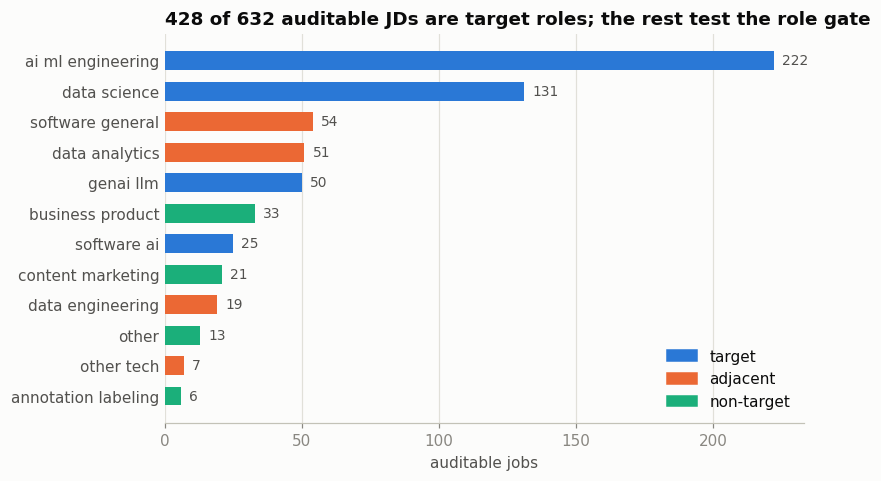

geo_stratum,foreign,indonesia,remote_unverified,All
role_group,,,,
adjacent,3,126,2,131
non_target,1,71,1,73
target,195,176,57,428
All,199,373,60,632


In [20]:
# Figure 4: role family counts for auditable jobs, colored by role group
fam_counts = AUD.role_family.value_counts()
groups = [role_group(f) for f in fam_counts.index]
color_of = {"target": SERIES[0], "adjacent": SERIES[1], "non_target": SERIES[2]}
fig, ax = plt.subplots(figsize=(7.5, 4.6))
y = list(range(len(fam_counts)))[::-1]
ax.barh(y, fam_counts.values, color=[color_of[g] for g in groups], height=0.62)
ax.set_yticks(y, [f.replace("_", " ") for f in fam_counts.index]); ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False); ax.spines["left"].set_visible(False)
# Count labels at the bar tips, and a legend for the three role groups
for yi, v in zip(y, fam_counts.values):
    ax.text(v + 3, yi, f"{v}", va="center", color=INK_2, fontsize=9)
ax.legend(handles=[Patch(color=color_of[g], label=l) for g, l in (("target", "target"), ("adjacent", "adjacent"), ("non_target", "non-target"))],
          loc="lower right")
ax.set_title(f"{len(TGT)} of {len(AUD)} auditable JDs are target roles; the rest test the role gate")
ax.set_xlabel("auditable jobs")
save(fig, FIG / "fig04_role_family.png"); plt.show()
# Role group by collection group: where the comparison jobs come from
pd.crosstab(AUD.role_group, AUD.geo_stratum, margins=True)

**Result:**

- Target roles (428) are AI/ML engineering 222, data science 131, GenAI/LLM 50, and software AI 25.
- There are 204 comparison jobs, mostly software general (54), data analytics (51), and business/product (33).
- Almost all comparison jobs are in the Indonesia group (197 of 204). In contrast, the foreign group is almost all target roles (195 of 199), because the foreign queries only searched for target roles.

**What it means:**

- AI/ML engineering and data science dominate the target roles (353 of 428, or 82%). Combined numbers will be driven mostly by these two roles, and that is why skills are split by role in 4.5.
- Comparison jobs are important for testing the role gate. An evaluation that only has relevant jobs cannot measure whether the gate rejects the wrong ones.
- Because the comparison jobs are concentrated in Indonesia, the role gate evaluation results in CP2 need to be reported per region, so an average score does not hide failures in a specific group.

**Note:** this composition reflects the queries we chose, not the market share of each role.

**Next:** the right role is not always within reach for a beginner. We check the experience requirements.

### 4.2 How big is the early-career pool based on experience?

**Why:** JobFit's main users are fresh graduates and beginners with 0 to 2 years of experience. We need to know how many target jobs have a low experience signal, and how many actually ask for more experience.

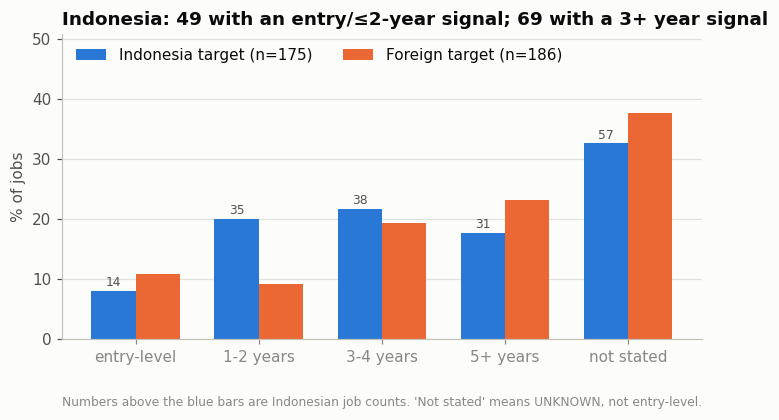

,Indonesia (n),Indonesia %,Foreign %
entry-level,14,8.0,10.8
1-2 years,35,20.0,9.1
3-4 years,38,21.7,19.4
5+ years,31,17.7,23.1
not stated,57,32.6,37.6


In [21]:
# Display labels for the experience buckets, in ORDER_E order
labels_e = ["entry-level", "1-2 years", "3-4 years", "5+ years", "not stated"]
# Bucket shares for Indonesian vs foreign target jobs, plus Indonesian counts
id_pct = ID_T.experience_bucket.value_counts(normalize=True).reindex(ORDER_E).fillna(0) * 100
for_pct = FOR_T.experience_bucket.value_counts(normalize=True).reindex(ORDER_E).fillna(0) * 100
id_n = ID_T.experience_bucket.value_counts().reindex(ORDER_E).fillna(0).astype(int)

# Figure 5: grouped bars, with Indonesian counts above the blue bars
fig, ax = plt.subplots(figsize=(7.5, 3.6))
x = range(len(ORDER_E)); w = 0.36
ax.bar([i - w/2 for i in x], id_pct.values, width=w, color=SERIES[0], label=f"Indonesia target (n={len(ID_T)})")
ax.bar([i + w/2 for i in x], for_pct.values, width=w, color=SERIES[1], label=f"Foreign target (n={len(FOR_T)})")
for i, (v, n) in enumerate(zip(id_pct.values, id_n.values)):
    ax.text(i - w/2, v + 0.8, f"{n}", ha="center", color=INK_2, fontsize=8)
ax.set_xticks(list(x), labels_e); ax.grid(axis="x", visible=False)
ax.set_ylabel("% of jobs"); ax.set_ylim(0, max(id_pct.max(), for_pct.max()) * 1.35)
ax.legend(loc="upper left", ncol=2)
# Title numbers: early-career signal (entry + 1-2y) vs 3+ years, from the counts
realistic_n = int(id_n["entry"] + id_n["1-2y"]); senior_n = int(id_n["3-4y"] + id_n["5y+"])
ax.set_title(f"Indonesia: {realistic_n} with an entry/≤2-year signal; {senior_n} with a 3+ year signal")
ax.text(0, -0.22, "Numbers above the blue bars are Indonesian job counts. 'Not stated' means UNKNOWN, not entry-level.",
        transform=ax.transAxes, color=MUTED, fontsize=8)
save(fig, FIG / "fig05_experience_requirement.png"); plt.show()
pd.DataFrame({"Indonesia (n)": id_n, "Indonesia %": id_pct.round(1), "Foreign %": for_pct.round(1)}).set_axis(labels_e)

**Result:**

- Of the **175 target jobs in Indonesia**: entry-level 14 (8%), 1-2 years 35 (20%), 3-4 years 38 (21.7%), 5+ years 31 (17.7%), and not stated 57 (32.6%).
- So **49 jobs (28%) are in the early-career pool**, **69 (39%) mention 3+ years**, and **57 (33%) are unclear**.
- Abroad, the early-career pool is only about 20% (entry 10.8% + 1-2 years 9.1%), while 42.5% mention 3+ years.

**What it means:**

- Picture 10 target jobs in Indonesia: about **3 could be options for a beginner, 4 are too senior, and 3 are unclear**. Without a seniority gate, 4 of 10 jobs shown to a beginner actually mention 3+ years.
- Foreign jobs are harder for beginners. This is relevant for the secondary persona who aims for international jobs.
- The "not stated" group is quite big (57). Treating it as a match would make the options look larger without evidence, while dropping all of it could remove relevant chances. The middle path is to show these jobs with UNKNOWN status and ask the user to check for themselves.

**Note:** these 49 jobs only passed the experience filter. Skills, education, location, and work permit are not checked yet, so this is not a recommendation yet. A 3+ year number can also be a preference or a requirement for another position in the same posting.

**Next:** if the early-career pool is only about a third, beginners need the right way to find it. Is searching for the word "junior" in the title enough?

### 4.3 Does the title reflect seniority?

**Why:** many job portals and job seekers filter jobs by words in the title. The table in 3.3 already hinted that this approach is weak. Here we look at the pattern visually, because this finding matters most for the seniority gate design.

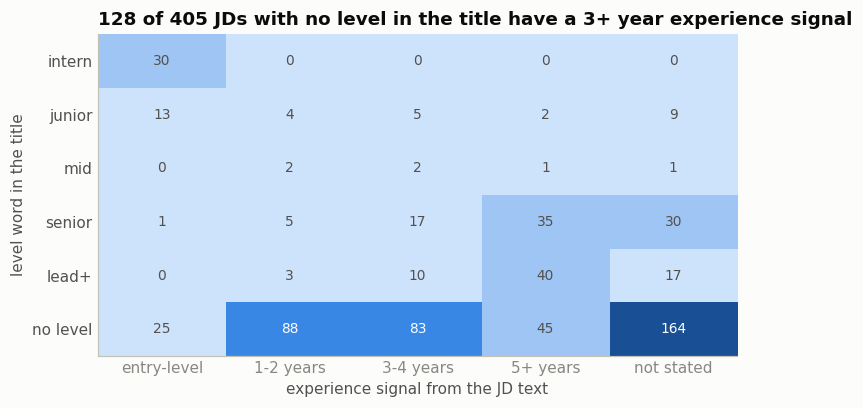

In [22]:
# Display labels for the title levels, in ORDER_T order
labels_t = ["intern", "junior", "mid", "senior", "lead+", "no level"]
# Reuse ORDER_T/ORDER_E from 3.3: title level vs experience bucket, all auditable jobs
ct = (pd.crosstab(pd.Categorical(AUD.title_seniority, ORDER_T), pd.Categorical(AUD.experience_bucket, ORDER_E))
        .reindex(index=ORDER_T, columns=ORDER_E).fillna(0).astype(int))
# Figure 6: heatmap with the count written in each cell
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.imshow(ct.values, cmap=ListedColormap(SEQ), aspect="auto")
ax.set_xticks(range(len(ORDER_E)), labels_e); ax.set_yticks(range(len(ORDER_T)), labels_t)
ax.grid(False); ax.tick_params(length=0)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, v, ha="center", va="center", fontsize=9, color=heat_text_color(v, ct.values.max()))
# Title number: jobs with no level in the title that still have a 3+ year signal
unspec_3plus = int(ct.loc["unspecified", ["3-4y", "5y+"]].sum()); unspec_total = int(ct.loc["unspecified"].sum())
ax.set_title(f"{unspec_3plus} of {unspec_total} JDs with no level in the title have a 3+ year experience signal")
ax.set_xlabel("experience signal from the JD text"); ax.set_ylabel("level word in the title")
save(fig, FIG / "fig06_title_vs_experience.png"); plt.show()

**Result:**

- The "no level" row is the biggest group (405 jobs), and it is spread across all columns: 25 entry, 88 1-2 years, 83 3-4 years, 45 5+ years, and 164 not stated.
- Senior and lead titles are fairly consistent. Only 6 of 88 senior jobs and 3 of 70 lead+ jobs have a signal of 2 years or less.
- Junior titles are not always safe, because 7 of 33 mention 3+ years.
- In the early-career pool (see 4.9), **37 of 49 jobs (75.5%) have no level word in the title**.

**What it means:** if only the title is used, mistakes can happen in two directions:

1. **Too senior but looks safe.** A title without the word "senior" actually asks for 3+ years (128 jobs).
2. **Fits a beginner but is not visible.** Jobs within reach for beginners do not write "junior" or "intern" (37 of 49).

So the title is only useful as an extra signal, mainly to flag senior and lead jobs. To be sure a job fits a beginner, JobFit has to read the JD text. This is the most important finding for the seniority gate design.

**Note:** this heatmap does not measure how well a search engine (one that understands meaning, not only words) finds beginner jobs. That is measured with Recall@K in CP2.

**Next:** after experience, we look at which skills are mentioned most in Indonesian target jobs.

### 4.4 Most mentioned skills in Indonesia

**Why:** the skill gap and Market Intelligence need a priority order of skills. We start from the combined numbers of all target roles in Indonesia.

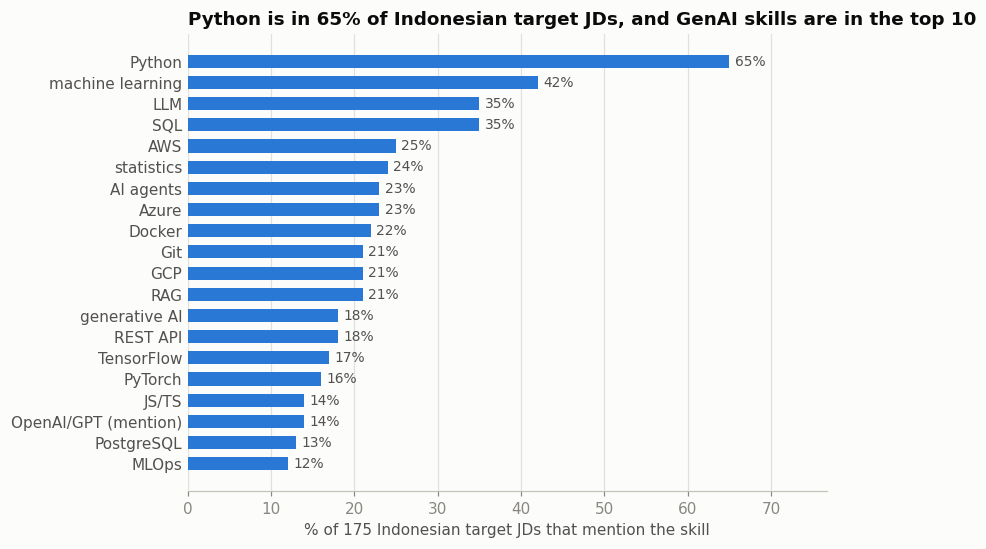

Indonesian target JDs that mention at least one GenAI skill: 49%


,skill,n,pct,category
0,python,114,65.1,language
1,machine_learning,74,42.3,ml_concept
2,llm,62,35.4,genai
3,sql,62,35.4,language
4,aws,43,24.6,cloud
5,statistics,42,24.0,ml_concept
6,ai_agents,41,23.4,genai
7,azure,40,22.9,cloud
8,docker,39,22.3,mlops_devops
9,git,37,21.1,mlops_devops


In [23]:
# Top 20 skills in Indonesian target jobs, as % of the ID_T jobs
cnt = Counter(s for sk in ID_T.skills for s in sk)
top = pd.DataFrame(cnt.most_common(20), columns=["skill", "n"])
top["pct"] = 100 * top.n / len(ID_T)
# Figure 7: horizontal bars of the top skills
fig, ax = plt.subplots(figsize=(7.5, 5.4))
barh(ax, [label_skill(s) for s in top.skill], top.pct.round(0).tolist(), fmt="{:.0f}%")
ax.set_title(f"Python is in {top.pct.iloc[0]:.0f}% of Indonesian target JDs, and GenAI skills are in the top 10")
ax.set_xlabel(f"% of {len(ID_T)} Indonesian target JDs that mention the skill")
save(fig, FIG / "fig07_top_skills_indonesia.png"); plt.show()
# Share of Indonesian target JDs with at least one skill from the GENAI list
genai_id = 100 * ID_T.skills.apply(lambda s: bool(set(s) & set(GENAI))).mean()
print(f"Indonesian target JDs that mention at least one GenAI skill: {genai_id:.0f}%")
# Top 10 with the skill category from the alias file
top.assign(category=top.skill.apply(skill_category)).head(10).round(1)

**Result:**

- Top 10 skills in the 175 Indonesian target jobs: Python 65.1%, machine learning 42.3%, LLM 35.4%, SQL 35.4%, AWS 24.6%, statistics 24.0%, AI agents 23.4%, Azure 22.9%, Docker 22.3%, and Git 21.1%.
- **49.1% of Indonesian target JDs mention at least one GenAI skill** (LLM, generative AI, RAG, agents, prompt engineering, fine-tuning, vector DB, or LangChain). Abroad the number is 59.7%.

**What it means:**

- **Python is almost a base requirement.** After Python, needs split into three directions: ML and data (machine learning, SQL, statistics), LLM and GenAI (LLM, AI agents), and cloud and tooling (AWS, Azure, Docker, Git).
- **GenAI is already common.** Almost half of the Indonesian target jobs mention a GenAI skill, so JobFit's skill dictionary and Market Intelligence must cover GenAI terms.
- But this list **combines all roles**. LLM and SQL are both at 35%, but they are not necessarily asked for in the same jobs. For accurate learning advice, this list has to be split by role.

**Next:** combined numbers can mislead, because each role mentions different skills. We split them by role family.

### 4.5 Skills by role family

**Why:** JobFit users usually aim for one role. If skill advice came from combined numbers, a future Data Scientist could be told to learn AI agents even though that skill is rarely asked for in that role. So that each role has enough samples, the heatmap uses all 428 target jobs (all regions), and the Indonesian pattern is checked separately in the table below it.

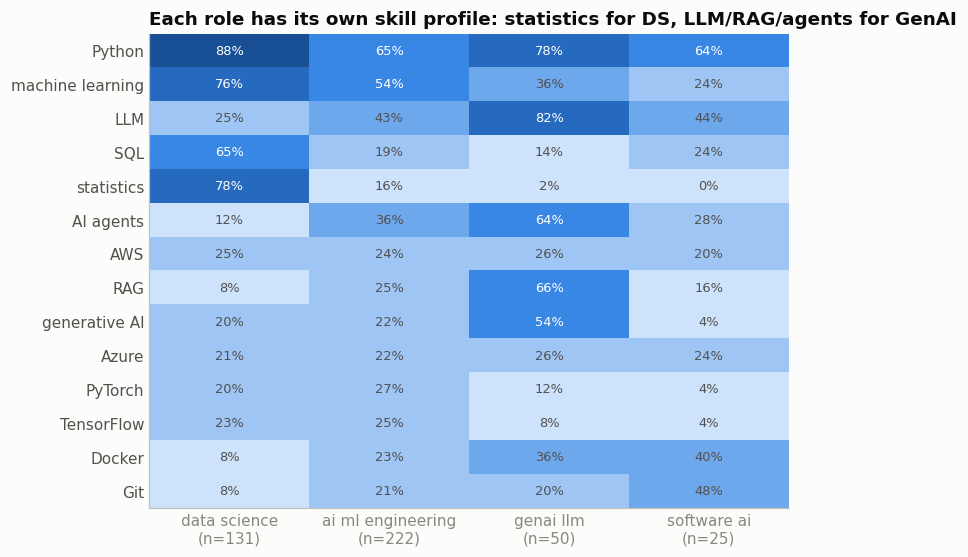

Check the pattern in Indonesia only (% of Indonesian target JDs per role):


,data_science (n=49),ai_ml_engineering (n=92),genai_llm (n=16),software_ai (n=18)
Python,90.0,52.0,69.0,61.0
machine learning,67.0,36.0,25.0,22.0
LLM,14.0,40.0,75.0,33.0
SQL,65.0,24.0,19.0,28.0
statistics,78.0,4.0,0.0,0.0
AI agents,2.0,29.0,50.0,28.0
AWS,22.0,26.0,19.0,28.0
RAG,6.0,24.0,62.0,11.0


In [24]:
# Heatmap data: the 14 most common target skills x the four target families (all regions)
FAMS = ["data_science", "ai_ml_engineering", "genai_llm", "software_ai"]
fam_n = {f: int((TGT.role_family == f).sum()) for f in FAMS}
sk_rows = [s for s, _ in Counter(s for x in TGT.skills for s in x).most_common(14)]
heat = pd.DataFrame({f: [share(TGT[TGT.role_family == f], s) for s in sk_rows] for f in FAMS}, index=sk_rows)

# Figure 8: % of JDs per family that mention each skill, on a fixed 0-100 color scale
fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.imshow(heat.values, cmap=ListedColormap(SEQ), aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(FAMS)), [f"{f.replace('_', ' ')}\n(n={fam_n[f]})" for f in FAMS])
ax.set_yticks(range(len(sk_rows)), [label_skill(s) for s in sk_rows])
ax.grid(False); ax.tick_params(length=0)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8.5, color=heat_text_color(v, 100))
ax.set_title("Each role has its own skill profile: statistics for DS, LLM/RAG/agents for GenAI")
save(fig, FIG / "fig08_skills_by_role.png"); plt.show()

# Same check on Indonesian target jobs only, top 8 skills (small groups, read with care)
print("Check the pattern in Indonesia only (% of Indonesian target JDs per role):")
id_heat = pd.DataFrame({f"{f} (n={int((ID_T.role_family == f).sum())})": [share(ID_T[ID_T.role_family == f], s) for s in sk_rows[:8]]
                        for f in FAMS}, index=[label_skill(s) for s in sk_rows[:8]]).round(0)
id_heat

**Result (all target jobs):**

- **Data science (131):** Python 88%, statistics 78%, machine learning 76%, SQL 65%. In contrast, RAG is only 8% and AI agents 12%.
- **GenAI/LLM (50):** LLM 82%, Python 78%, RAG 66%, AI agents 64%, generative AI 54%. Statistics is only 2%.
- **AI/ML engineering (222):** a mix: Python 65%, machine learning 54%, LLM 43%, and AI agents 36%.
- **Software AI (25):** closer to software engineering: Git 48%, LLM 44%, Docker 40%, while machine learning is 24%.
- **The pattern in Indonesia is the same:** Indonesian data science mentions statistics 78% and SQL 65%, while Indonesian GenAI/LLM mentions LLM 75% and RAG 62%.

**What it means:**

- Each role has **its own skill bundle**. Data scientists lean on statistics, SQL, and ML. GenAI engineers lean on LLM, RAG, and agents. AI/ML engineering sits in the middle, and software AI asks more for software tooling.
- An example of the impact: if skill advice came from combined numbers, a future data scientist could be told to learn RAG, even though only 8% of data science JDs mention it. On the other side, a future GenAI engineer does not need to prioritize statistics (2%).
- This also shows the weakness of a keyword overlap score. Two candidates with the same number of skills can fit very different roles. So **JobFit's skill gap and market insight have to be computed per role family**.

**Note:** this is one snapshot, so it cannot show trends over time. The role family still comes from the title, and small groups (GenAI Indonesia 16, software AI Indonesia 18) make their percentages swing easily.

**Next:** GenAI skills appear in almost every target role. We check whether they appear one by one, or often together.

### 4.6 GenAI skill bundle

**Why:** if LLM, RAG, and agents often appear together, the skill gap explanation can be grouped instead of shown as a list of separate skills. We compare JDs that mention LLM with JDs that do not.

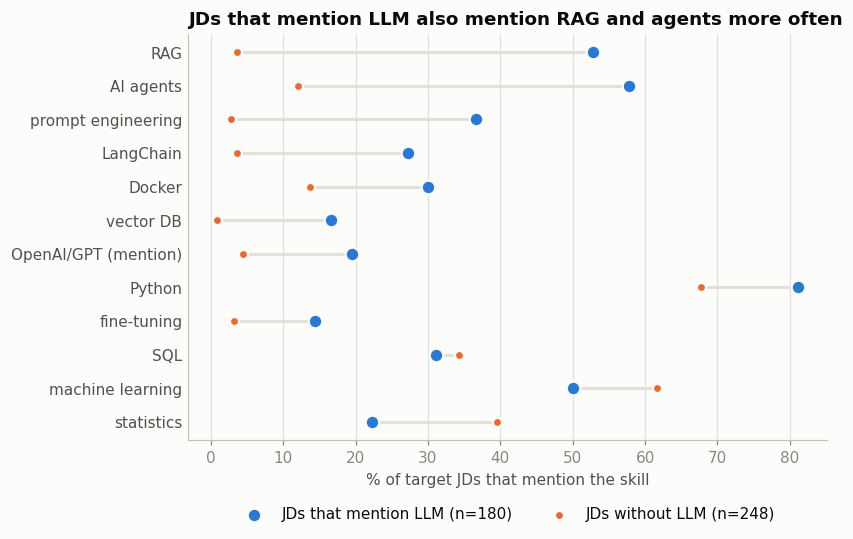

,skill,with LLM,without LLM,difference
0,rag,53.0,4.0,49.0
1,ai_agents,58.0,12.0,46.0
2,prompt_engineering,37.0,3.0,34.0
3,langchain,27.0,4.0,24.0
7,docker,30.0,14.0,16.0
5,vector_database,17.0,1.0,16.0
4,openai_api,19.0,4.0,15.0
8,python,81.0,68.0,13.0
6,fine_tuning,14.0,3.0,11.0
10,sql,31.0,34.0,-3.0


In [25]:
# Split target jobs by whether the JD mentions LLM
has_llm = TGT.skills.apply(lambda s: "llm" in s)
with_llm, without_llm = TGT[has_llm], TGT[~has_llm]
# GenAI tools plus a few general skills as reference; difference = with minus without
bundle = ["rag", "ai_agents", "prompt_engineering", "langchain", "openai_api", "vector_database", "fine_tuning",
          "docker", "python", "machine_learning", "sql", "statistics"]
co = pd.DataFrame({"skill": bundle,
                   "with LLM": [share(with_llm, s) for s in bundle],
                   "without LLM": [share(without_llm, s) for s in bundle]})
co["difference"] = co["with LLM"] - co["without LLM"]
co = co.sort_values("difference")

# Figure 9: dumbbell chart, one line per skill between the two groups
fig, ax = plt.subplots(figsize=(7.5, 4.8))
yy = range(len(co))
ax.hlines(list(yy), co[["with LLM", "without LLM"]].min(axis=1), co[["with LLM", "without LLM"]].max(axis=1), color="#e1e0d9", linewidth=2)
ax.scatter(co["with LLM"], list(yy), s=80, color=SERIES[0], zorder=3, label=f"JDs that mention LLM (n={len(with_llm)})", edgecolors="#fcfcfb", linewidths=1.5)
ax.scatter(co["without LLM"], list(yy), s=36, color=SERIES[1], zorder=3, label=f"JDs without LLM (n={len(without_llm)})", edgecolors="#fcfcfb", linewidths=1.5)
ax.set_yticks(list(yy), [label_skill(s) for s in co.skill]); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
ax.set_xlabel("% of target JDs that mention the skill"); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
ax.set_title("JDs that mention LLM also mention RAG and agents more often")
save(fig, FIG / "fig09_genai_bundle.png"); plt.show()
co.sort_values("difference", ascending=False).round(0)

**Result:** of the 428 target jobs, 180 mention LLM and 248 do not.

| Skill | JDs with LLM | JDs without LLM |
| --- | ---: | ---: |
| RAG | 53% | 4% |
| AI agents | 58% | 12% |
| Prompt engineering | 37% | 3% |
| LangChain | 27% | 4% |
| Docker | 30% | 14% |
| Vector DB | 17% | 1% |
| Statistics | 22% | 40% |
| Machine learning | 50% | 62% |

**What it means:**

- **GenAI skills tend to appear together.** JDs that mention LLM mention RAG about 13 times more often, and AI agents almost 5 times more often.
- Docker also appears twice as often. This hints that some LLM jobs expect the ability to bring models into applications, not only to experiment in notebooks.
- In contrast, statistics and classic ML are mentioned less often in JDs that mention LLM.
- For JobFit, the gap explanation can be grouped, for example "there is evidence of LLM, but no evidence of RAG and agents yet". This idea is treated as a hypothesis to test in CP2.

**Note:** 47% of JDs that mention LLM do not mention RAG, so this pattern must not become a rule. JobFit still judges the gap from the requirements in the JD being viewed, not from corpus statistics. This pattern is also co-occurrence, not cause and effect. Following the Canonical document, skill ontology v1 stays as aliases and simple normalization, while more complex relations between skills remain an experiment option.

**Next:** so far we have used combined data a lot. Now we check whether Indonesian jobs are really different from foreign jobs.

### 4.7 Indonesia vs foreign

**Why:** JobFit focuses on Indonesia, but the corpus also has foreign jobs. If their skill profiles differ, the insights must not be combined. There is one trap: foreign JDs tend to be longer, and longer JDs usually mention more skills. So a difference could appear only because of text length. We check it in three ways:

1. **Raw comparison** (dumbbell chart).
2. **JDs of similar length**, that is 1,500 to 4,000 characters.
3. **Standardization**, which compares only the role and JD length groups that exist in both regions (at least 3 JDs per region), and then gives both regions the same weights.

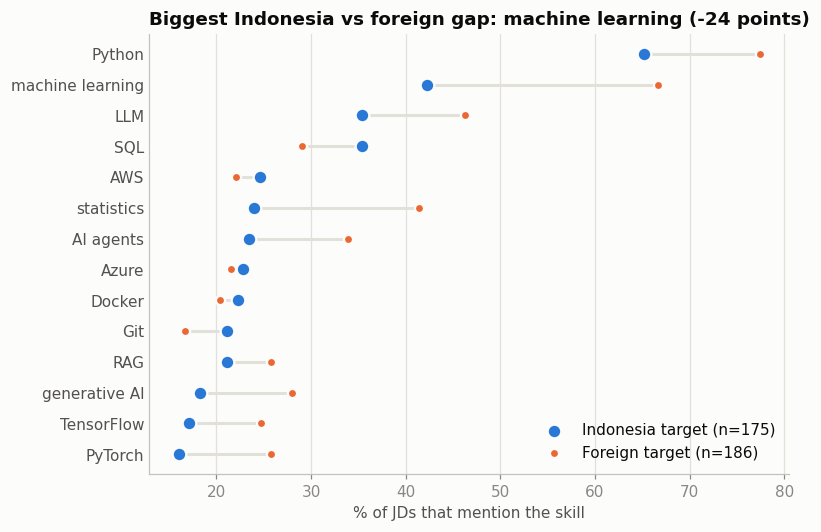

,median JD characters,average skills mentioned
Indonesia target,2420.0,7.6
Foreign target,3538.0,9.0


Similar-length comparison: Indonesia n=112, foreign n=100


Standardization on role × length bin; common support: {'ID': 151, 'foreign': 172} of {'ID': 175, 'foreign': 186}


,role_family,length_bin,ID,foreign,weight
0,ai_ml_engineering,<1500,20,8,0.086687
1,ai_ml_engineering,1500-2499,31,21,0.160991
2,ai_ml_engineering,2500-3999,25,25,0.154799
3,ai_ml_engineering,4000-5999,9,22,0.095975
4,ai_ml_engineering,>=6000,7,15,0.068111
5,data_science,<1500,7,3,0.030960
6,data_science,1500-2499,13,12,0.077399
7,data_science,2500-3999,19,19,0.117647
8,data_science,4000-5999,4,19,0.071207
9,data_science,>=6000,6,9,0.046440


,ID_pct,foreign_pct,difference_pp
ai_agents,25.0,28.3,-3.3
aws,26.5,20.3,6.2
azure,24.8,20.7,4.1
docker,19.3,18.1,1.3
generative_ai,21.8,24.8,-3.0
git,16.5,14.3,2.2
llm,39.1,41.2,-2.1
machine_learning,45.5,69.2,-23.7
python,67.1,75.7,-8.6
pytorch,16.7,27.3,-10.6


In [26]:
# Method 1 (raw): Indonesian vs foreign skill shares for the 14 most common skills
skills_cmp = [s for s, _ in Counter(s for sk in pd.concat([ID_T, FOR_T]).skills for s in sk).most_common(14)]
# One row per skill: share in Indonesian vs foreign JDs, and the difference in points
cmp = pd.DataFrame({"skill": skills_cmp, "Indonesia": [share(ID_T, s) for s in skills_cmp], "Foreign": [share(FOR_T, s) for s in skills_cmp]})
cmp["difference"] = cmp.Indonesia - cmp["Foreign"]
cmp = cmp.sort_values("Indonesia")
# Figure 10: dumbbell chart of the raw shares
fig, ax = plt.subplots(figsize=(7.5, 5.2))
yy = range(len(cmp))
ax.hlines(list(yy), cmp[["Indonesia", "Foreign"]].min(axis=1), cmp[["Indonesia", "Foreign"]].max(axis=1), color="#e1e0d9", linewidth=2)
ax.scatter(cmp.Indonesia, list(yy), s=80, color=SERIES[0], zorder=3, label=f"Indonesia target (n={len(ID_T)})", edgecolors="#fcfcfb", linewidths=1.5)
ax.scatter(cmp["Foreign"], list(yy), s=36, color=SERIES[1], zorder=3, label=f"Foreign target (n={len(FOR_T)})", edgecolors="#fcfcfb", linewidths=1.5)
ax.set_yticks(list(yy), [label_skill(s) for s in cmp.skill]); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
ax.set_xlabel("% of JDs that mention the skill"); ax.legend(loc="lower right")
biggest = cmp.loc[cmp.difference.abs().idxmax()]
ax.set_title(f"Biggest Indonesia vs foreign gap: {label_skill(biggest.skill)} ({biggest.difference:+.0f} points)")
save(fig, FIG / "fig10_skills_id_vs_foreign.png"); plt.show()

# Possible confounder: foreign JDs are longer and mention more skills
conf = pd.DataFrame({
    "median JD characters": [ID_T.clean_length.median(), FOR_T.clean_length.median()],
    "average skills mentioned": [ID_T.n_skills.mean(), FOR_T.n_skills.mean()],
}, index=["Indonesia target", "Foreign target"]).round(1)
display(conf)

# Method 2: compare only JDs of similar length (1,500 to 4,000 characters)
band = lambda d: d[d.clean_length.between(1500, 4000)]
bi, bf = band(ID_T), band(FOR_T)
cmp["difference_similar_length"] = [share(bi, s) - share(bf, s) for s in cmp.skill]
print(f"Similar-length comparison: Indonesia n={len(bi)}, foreign n={len(bf)}")
cmp.sort_values("difference")[["skill", "Indonesia", "Foreign", "difference", "difference_similar_length"]].round(0)
# Method 3: standardize on role x length bins; a length band alone does not balance them
standardized = standardized_skill_comparison(ID_T, FOR_T, sorted(set(skills_cmp) | {"sql", "machine_learning", "llm", "statistics", "rag", "git"}))
print("Standardization on role × length bin; common support:", standardized["retained_n"], "of", standardized["eligible_n"])
display(pd.DataFrame(standardized["strata"]))
display(pd.DataFrame(standardized["skills"]).T.round(1))


**Result:**

- Foreign JDs are indeed longer (median 3,538 vs 2,420 characters) and mention more skills (average 9.0 vs 7.6).
- **Raw comparison** (Indonesia minus foreign): machine learning −24.4 points, statistics −17.4, Python −12.3, LLM −10.8, AI agents −10.4. Indonesia is higher in SQL (+6.4) and Git (+4.5).
- **After standardization** (151 Indonesian jobs and 172 foreign jobs in 12 role and JD length groups):

| Skill | Raw difference | Difference after standardization |
| --- | ---: | ---: |
| Machine learning | −24.4 | −23.7 |
| Statistics | −17.4 | −11.4 |
| SQL | +6.4 | +8.8 |
| LLM | −10.8 | −2.1 |
| AI agents | −10.4 | −3.3 |
| RAG | −4.7 | +3.2 |

**What it means:**

- **What holds:** Indonesia mentions SQL more often, and machine learning, statistics, and deep learning frameworks less often (PyTorch −10.6, TensorFlow −9.7). The Indonesian job profile leans more toward data and practical engineering.
- **What does not hold:** the impression that "Indonesia is behind in GenAI". The LLM and agents gaps almost disappear, and RAG even flips direction after role and JD length are balanced. This means the raw gap came mostly from the role mix and the longer foreign JDs.
- This is an example of why raw charts must not be turned directly into conclusions. For JobFit, market statistics have to be split by region and by role.

**Note:** software AI does not have enough data in both regions, so it is not included in the standardization. These results are descriptive for the corpus, not a statistical significance test, and can still be affected by publisher, employer, and language.

**Next:** besides skills, the most basic filter for users is location and work mode.

### 4.8 Location and work mode

**Why:** location is the most basic eligibility check, because an onsite job in a city the user cannot reach is not relevant. Work mode is used in the preference layer. We need to know how concentrated the jobs are and whether the work mode data is good enough to use.

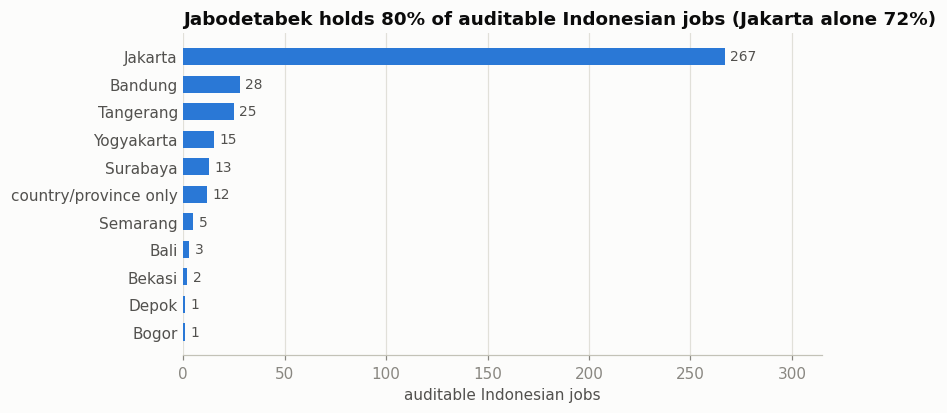

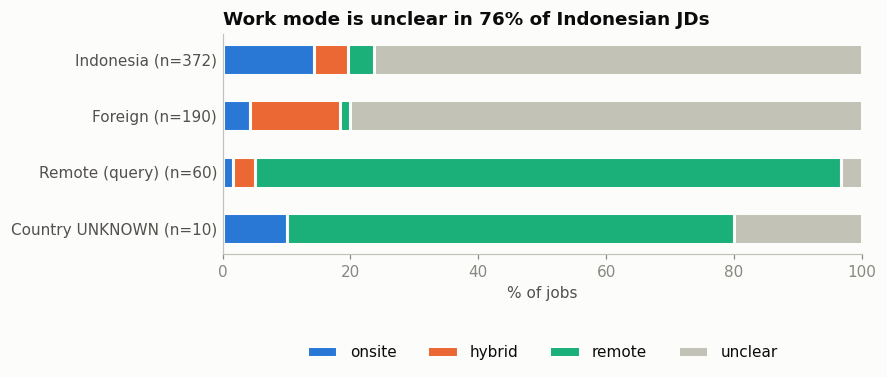

mode,onsite,hybrid,remote,unclear
analysis_geo,,,,
indonesia,14.2,5.4,4.0,76.3
foreign,4.2,14.2,1.6,80.0
remote_unverified,1.7,3.3,91.7,3.3
unknown,10.0,0.0,70.0,20.0


In [27]:
# Cities of all auditable Indonesian jobs (all roles); no city = country/province only
id_aud = AUD[AUD.analysis_geo == "indonesia"]
cities = id_aud.city_normalized.fillna("country/province only").value_counts()
jkt_share = 100 * cities.get("Jakarta", 0) / cities.sum()
jabo = 100 * (id_aud.metro == "Jabodetabek").mean()
# Figure 11: job counts per city
fig, ax = plt.subplots(figsize=(7.5, 3.8))
barh(ax, cities.index.tolist(), cities.values.tolist())
ax.set_title(f"Jabodetabek holds {jabo:.0f}% of auditable Indonesian jobs (Jakarta alone {jkt_share:.0f}%)")
ax.set_xlabel("auditable Indonesian jobs")
save(fig, FIG / "fig11_indonesia_cities.png"); plt.show()

# Work mode per region: remote_mentioned and unknown are merged into "unclear"
wm = AUD.copy()
wm["mode"] = wm.work_mode.replace({"remote_mentioned": "unclear", "unknown": "unclear"})
modes = ["onsite", "hybrid", "remote", "unclear"]
tab = pd.crosstab(wm.analysis_geo, wm["mode"], normalize="index").reindex(columns=modes).fillna(0).mul(100)
tab = tab.reindex([g for g in ["indonesia", "foreign", "remote_unverified", "unknown"] if g in tab.index])
# Figure 12: 100% stacked bars, one row per analysis region
fig, ax = plt.subplots(figsize=(7.5, 2.6))
left = np.zeros(len(tab))
for m, c in zip(modes, [SERIES[0], SERIES[1], SERIES[2], NEUTRAL]):
    ax.barh(range(len(tab)), tab[m], left=left, color=c, height=0.55, label=m, edgecolor="#fcfcfb", linewidth=2)
    left += tab[m].values
ax.set_yticks(range(len(tab)), [{"indonesia": "Indonesia", "foreign": "Foreign", "remote_unverified": "Remote (query)", "unknown": "Country UNKNOWN"}[g] + f" (n={int((AUD.analysis_geo == g).sum())})" for g in tab.index]); ax.invert_yaxis()
ax.grid(False); ax.set_xlim(0, 100); ax.set_xlabel("% of jobs"); ax.tick_params(axis="y", length=0)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.35))
ax.set_title(f"Work mode is unclear in {tab.loc['indonesia', 'unclear']:.0f}% of Indonesian JDs")
save(fig, FIG / "fig12_work_mode.png"); plt.show()
tab.round(1)

**Result:**

- Of the **372 Indonesian candidates**, **79.6% are in Jabodetabek**. Jakarta alone has 267 jobs (71.8%). Other cities have far fewer: Bandung 28, Tangerang 25, Yogyakarta 15, and Surabaya 13. 12 jobs only mention the country or province.
- Work mode is **unclear in 76.3% of Indonesian JDs** and 80% of foreign JDs. In Indonesia, only onsite 14.2%, hybrid 5.4%, and remote 4.0% are clearly written.

**What it means:**

- **Almost 8 in 10 Indonesian jobs in the corpus are in Jabodetabek.** Users outside Jabodetabek will see far fewer onsite options. So location deserves to be an early check, and JobFit needs to be honest about the city coverage in the data.
- **Work mode is rarely written.** If a user picks "remote only" and all unclear jobs are rejected, about 3 in 4 jobs disappear only because the JD does not state it. So work mode should just be a soft preference, and unclear values are shown as they are. Following the Canonical document, preferences like work mode are kept separate from the qualification assessment.

**Note:** this concentration is also affected by the cities we chose in the queries and by the coverage of the data source, so it does not prove that other cities have no jobs.

**Next:** all filters have been looked at one by one. Now we combine them and look at the jobs that will become the first options for beginners in Indonesia.

### 4.9 Early-career pool: roles, skills, and education

**Why:** this pool is the Indonesian target jobs with an entry-level signal or at most 2 years of experience. It is the closest picture of what JobFit's main users will see, even though it is not a personal recommendation yet. From here we learn whether the count is enough for a demo, which roles and cities dominate, and which skills and education levels are mentioned most. Education level is read with the simple `education_levels` rule, which only records the levels that are mentioned, without separating required and optional.

Early-career pool by experience: 49 jobs from 49 companies


jobs
role family     ai_ml_engineering    26
                data_science         15
                software_ai           6
                genai_llm             2
region          Jabodetabek          40
                Surabaya              5
                Bandung               2
                Yogyakarta            1
                Semarang              1
employment type full_time            34
                contract             10
                internship            3
                unknown               1
                part_time             1
level in title  unspecified          37
                intern                6
                junior                5
                mid                   1

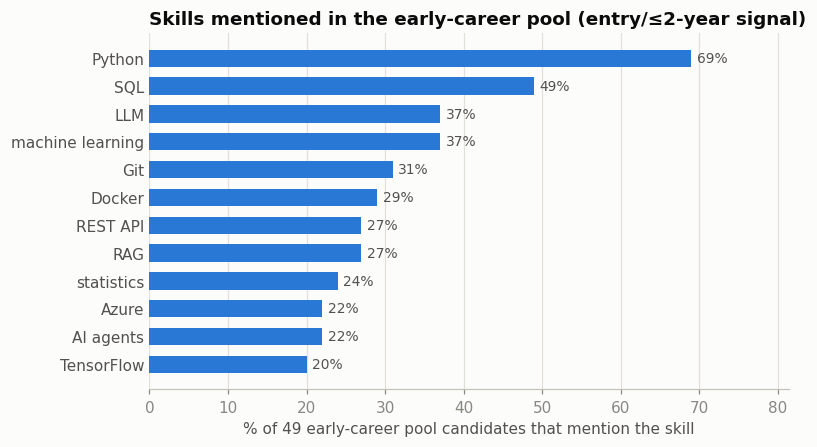

,early-career pool (n=49),Indonesia 3+ years (n=69),Indonesia target (n=175),foreign target (n=186)
diploma,6.0,3.0,3.0,3.0
bachelor,57.0,48.0,44.0,44.0
master,12.0,23.0,15.0,27.0
phd,0.0,7.0,5.0,13.0
no_level_mentioned,39.0,41.0,49.0,44.0


In [28]:
from jobfit.jobs.transform import education_levels

# Early-career pool: Indonesian target jobs with an entry or 1-2y signal; SEN = 3+ years
REAL = ID_T[ID_T.experience_bucket.isin(["entry", "1-2y"])]
SEN = ID_T[ID_T.experience_bucket.isin(["3-4y", "5y+"])]
# Pool profile by role, region, employment type, and title level
profile = pd.concat({
    "role family": REAL.role_family.value_counts(),
    "region": REAL.metro.fillna(REAL.city_normalized).fillna("unknown").value_counts(),
    "employment type": REAL.employment_type_normalized.value_counts(),
    "level in title": REAL.title_seniority.value_counts(),
}).rename("jobs").to_frame()
print(f"Early-career pool by experience: {len(REAL)} jobs from {REAL.company.nunique()} companies")
display(profile)

# Figure 13: top 12 skills in the pool, as % of pool jobs
cnt_r = Counter(s for sk in REAL.skills for s in sk)
top_r = pd.DataFrame(cnt_r.most_common(12), columns=["skill", "n"])
top_r["pct"] = 100 * top_r.n / len(REAL)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
barh(ax, [label_skill(s) for s in top_r.skill], top_r.pct.round(0).tolist(), fmt="{:.0f}%")
ax.set_title(f"Skills mentioned in the early-career pool (entry/≤2-year signal)")
ax.set_xlabel(f"% of {len(REAL)} early-career pool candidates that mention the skill")
save(fig, FIG / "fig13_realistic_pool_skills.png"); plt.show()

# % of jobs that mention each education level, plus jobs that mention no level
def edu_table(df):
    lv = df.description_clean.apply(education_levels)
    row = {k: 100 * lv.apply(lambda l: k in l).mean() for k in ["diploma", "bachelor", "master", "phd"]}
    row["no_level_mentioned"] = 100 * lv.str.len().eq(0).mean()
    return row
# Pool vs Indonesian 3+ year jobs, all Indonesian targets, and foreign targets
pd.DataFrame({f"early-career pool (n={len(REAL)})": edu_table(REAL), f"Indonesia 3+ years (n={len(SEN)})": edu_table(SEN),
              f"Indonesia target (n={len(ID_T)})": edu_table(ID_T), f"foreign target (n={len(FOR_T)})": edu_table(FOR_T)}).round(0)

**Result:**

- The early-career pool has **49 jobs from 49 different companies**.
- **Role:** AI/ML engineering 26, data science 15, software AI 6, and GenAI/LLM only 2.
- **Region:** Jabodetabek 40 (82%), Surabaya 5, Bandung 2, Yogyakarta 1, and Semarang 1.
- **Employment type:** full-time 34, contract 10, internship 3, part-time 1, and unknown 1.
- **Level in the title:** 37 with no level, 6 intern, 5 junior, and 1 mid.
- **Most mentioned skills:** Python 34 (69%), SQL 24 (49%), LLM 18 (37%), machine learning 18 (37%), Git 15 (31%), Docker 14 (29%), RAG 13 (27%), and REST API 13 (27%).
- **Education:** a bachelor's degree (S1) is mentioned in 28 jobs (57%), a master's (S2) in 6 (12%), a diploma in 3 (6%), a doctorate (S3) in none, and 19 (39%) do not mention an education level. For comparison, S2 is mentioned in 23% of Indonesian 3+ year jobs and 27% of foreign jobs.

**What it means:**

- **Options for beginners are few but varied.** No single company dominates. The number is enough for a demo, but JobFit has to be honest that options for beginners are limited.
- **GenAI jobs are rarely open to beginners in this corpus.** Only 2 of the 16 Indonesian GenAI/LLM jobs are in the pool. But 16 is too small to conclude that the GenAI market is closed to beginners.
- **Base skills for beginners:** Python and SQL are mentioned most, then ML and LLM, then Git and Docker. SQL stands out more in the early-career pool (49%) than across all Indonesian target jobs (35%), but this comparison does not account for the role mix yet, so it is still an exploratory direction.
- **S1 is mentioned most**, while S2 is much rarer in the early-career pool than in senior and foreign jobs. So education level deserves a place in the user profile and the extraction schema. Education percentages do not have to add up to 100%, because one JD can mention several levels, for example "S1, S2 diutamakan" ("S1, S2 preferred").

**Note:** 30 of these 49 jobs are still in the review queue, all because their experience quote contains words like "preferred", "or", or "atau". This pool is an early filter based on the experience signal, not a recommendation, and the fit on skills, education, location, and CV evidence is assessed in CP2.

**Next:** before drawing conclusions, we check one more thing that could bias the insights: where the data comes from.

### 4.10 Job sources

**Why:** if most data comes from only a few publishers, the insights inherit those publishers' bias, for example the type of companies, the JD writing style, or metadata completeness. This needs to be stated in the limitations.

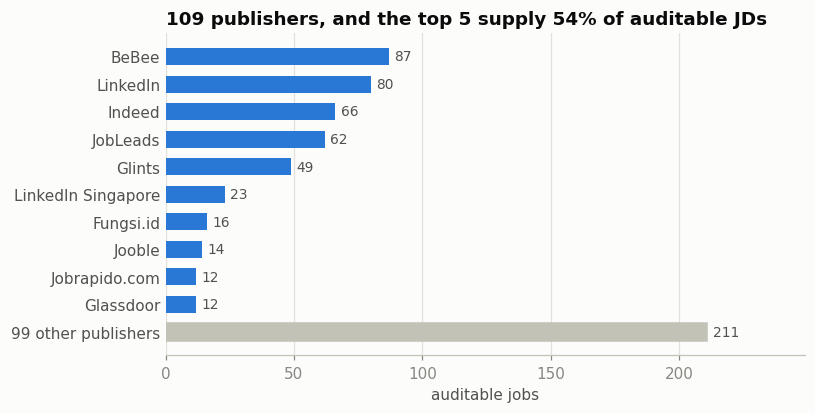

In [29]:
# Figure 14: top 10 publishers of auditable JDs, with the rest grouped into one bar
pubs = AUD.source_platform.value_counts()
top_p = pubs.head(10)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
other_n = int(pubs.iloc[10:].sum())
barh(ax, top_p.index.tolist() + [f"{len(pubs) - 10} other publishers"], top_p.values.tolist() + [other_n])
# Gray out the grouped bar so it does not read as one big publisher
for bar in ax.patches:
    if bar.get_width() == other_n:
        bar.set_color(NEUTRAL)  # combined small publishers, not a single publisher
ax.set_title(f"{len(pubs)} publishers, and the top 5 supply {100 * pubs.head(5).sum() / pubs.sum():.0f}% of auditable JDs")
ax.set_xlabel("auditable jobs")
save(fig, FIG / "fig14_publishers.png"); plt.show()

**Result:**

- EDA candidates come from **109 publishers**, but **the top 5 supply 54.4%**: BeBee 87, LinkedIn 80, Indeed 66, JobLeads 62, and Glints 49.
- Local portals like Jobstreet (11) and Kalibrr (3) appear only a little.

**What it means:**

- The findings in this notebook describe **jobs visible through Google for Jobs**, not the whole market. Jobs posted only on certain local portals may be under-represented.
- Many publishers does not mean independent sources, because aggregators often copy the same job from other sources.
- Writing style, JD length, and metadata completeness are also shaped by the big publishers. In the presentation, it needs to be said that the data comes from JSearch coverage in a two-day snapshot.

**Next:** we summarize all findings into design decisions for the implementation stage.

## 5. Insight, design decisions, and next steps

### 5.1 Answers to the four questions

**1. Can the data be trusted?**

For job identity and JD text, mostly yes. The raw data is locked with hashes, duplicates are removed (1,314 slots become 910 jobs), and 632 EDA candidates have JD text that is long enough. But structured metadata is weak (date 30%, city 20%, salary 3%). Dedup is still v0 (the 3 UNSURE pairs are flagged for re-check), and all labels are rule-based v0, to be validated with the CP2 gold set.

**2. What features can be built?**

Role family, experience signal with its evidence quote, country and city, work mode, remote eligibility signal, 64 canonical skills, and education level. All of them are versioned and can be traced to the raw data.

**3. What is inside the job postings in this corpus?**

Only 49 of 175 Indonesian target jobs (28%) are within reach for beginners based on the experience signal, and 37 of them do not write a level in the title. Required skills clearly differ by role, GenAI skills appear as a bundle, and Indonesian jobs mention SQL more but ML less than foreign jobs. Jobs are highly concentrated in Jabodetabek, and work mode is rarely written.

**4. What design decisions come from the data?**

See table 5.2.

### 5.2 From findings to design decisions

| Finding | Evidence | Decision for JobFit | Validated in CP2 with |
| --- | --- | --- | --- |
| The title cannot be used to judge the level | 128 of 405 JDs with no level mention 3+ years. 37 of 49 beginner jobs have no level in the title (3.3, 4.3) | The seniority gate reads the requirement in the JD text and shows its quote | Required/preferred gold set, multi-level cases |
| The word "AI" in a title can be misleading | 49 of 463 "AI" titles are not target roles (3.2) | A role gate based on role family before ranking | Wrong-role false-positive rate on hard negatives |
| The early-career pool is small, and many jobs are unclear | 49 of 175 have a ≤2 year signal, 57 not stated (4.2) | UNKNOWN is shown as it is, not treated as a match. Qualification is judged from the CV and the requirements | Precision@5, NDCG@10, seniority false-positive rate |
| Skills differ by role | Statistics 78% in DS, 2% in GenAI (4.5) | Skill gap and market insight are computed per role family | Skill extraction evaluation per role |
| GenAI skills appear as a bundle | RAG 53% vs 4%, agents 58% vs 12% (4.6) | The gap explanation can be grouped. Ontology v1 stays as simple aliases | Experiment on the explanation format |
| Indonesia differs from other countries | After standardization, SQL +8.8 and ML −23.7 points (4.7) | Market statistics are split by region and by role | Per-region reports |
| Locations are concentrated, and work mode is rarely written | 79.6% Jabodetabek, 76% unclear mode (4.8) | Location is checked as eligibility. Work mode becomes a soft preference | Location and work permit labels |
| Remote does not always mean open to Indonesia | 3 of 85 mention Indonesia, 11 restricted to other countries (3.4) | Remote is not automatically treated as eligible | Remote eligibility labels |
| Weak metadata, requirements are in the text | posted_at 30%, city 20%, highlights 0% (2.1) | Extraction from the JD text. Dates always come with a source label | Precision, recall, F1, schema validity, cost and latency |
| Some JDs are in Indonesian | 25 of 175 Indonesian target jobs (2.5) | The skill dictionary and the extractor are tested in two languages | Gold set with Indonesian and English JDs |

### 5.3 What is fact, hypothesis, and target

When used for the presentation, these three kinds of statements need to be kept apart because their evidence status is different:

| Type | Example |
| --- | --- |
| **Fact from CP1** (computed in this notebook) | 49 of 175 Indonesian target jobs have a ≤2 year signal. 128 of 405 JDs with no level mention 3+ years. |
| **Design hypothesis** (expected to help, not proven yet) | A seniority gate based on the JD text will reduce jobs that are too senior in the top results. A grouped gap explanation is easier to understand. |
| **CP2 target** (to be measured) | Precision@5, NDCG@10, wrong-role and seniority false-positive rate, and extraction F1. |

### 5.4 Limitations

- **Query-based sample** from one provider over two days. It does not represent the whole market or time trends, and saturation only applies to the queries that were tested.
- **The `full` or `auditable` label** is based only on a minimum text length of 700 characters and the generic form filter. It is not proof of an official source, complete requirements, or a job that is still active.
- **Dedup** is still v0. It includes 40 pair decisions reviewed against the text evidence, and the 3 UNSURE pairs are flagged for re-check. Clusters may be wrongly merged, or duplicates may remain.
- **The v0.1 labels have no accuracy score yet.** The highest experience number can be mixed with preferences, alternatives, negation, or multi-level jobs. Numbers above 15 years are not detected yet.
- **Skills and education are mentions only.** UNKNOWN does not mean there is no requirement. Language and work mode detection are also still heuristic.
- **Dates from relative text** are only estimates, and posting age does not prove a job is still active. Contact masking is also not full anonymization.
- **The regional comparison** only applies to groups that can be compared (software AI is not included), and there is no claim of cause and effect or statistical significance.

### 5.5 Is more data needed?

There is no extra collection for this notebook. What is needed most now is **the CP2 gold set (manually labeled evaluation set)**, not more jobs up to 1,000. The gold set also has to be kept apart from the examples already used to improve the rules, so the evaluation does not leak. Cases already found during the audit go into the development set. Salary is still treated as a preference and is too rarely filled to analyze.

### 5.6 Next steps

1. **Build the CP1 PPT** from the figures and `CP1_research_summary.json`, then record the mentor feedback.
2. **Re-check the duplicate decisions**, especially the 3 UNSURE pairs, and start from the review queue of 260 candidates.
3. **Prepare the CP2 evaluation datasets** following the Canonical document: extraction gold of about 50 JDs, about 100 evidence pairs, a ranking set of 40 to 60 jobs, a RAG evaluation of 15 to 20 questions, and CV safety with 20 to 30 scenarios.
4. **Compare baselines**: keyword, FTS, dense, and hybrid RRF, and also rule-based v0 against the LLM extractor, on a frozen split. The reranker and complex skill relations stay optional. No model evaluation results may be claimed in CP1.

The last cell saves the main numbers, data counts, rule versions, and code hashes to `data/processed/CP1_research_summary.json`, so the documents and PPT quote the same numbers as this notebook.

In [30]:
# Save key numbers as JSON so other docs (inventory, insights, PPT) quote the same values
summary = {
    "snapshot": "CP1_20260926", "cleaning_version": CLEANING_VERSION, "taxonomy_version": TAXONOMY_VERSION,
    "skill_alias_version": alias_version,
    "funnel": dict(zip(funnel.stage, funnel.n.astype(int))),
    "completeness_auditable_pct": dict(zip(completeness.field, completeness["complete_auditable_%"])),
    "jd_quality": canon.jd_quality.value_counts().to_dict(),
    "jd_language_by_geo": pd.crosstab(canon.geo_stratum, canon.jd_language).to_dict(orient="index"),
    "posted_at_source": canon.posted_at_source.value_counts().to_dict(),
    "dedup_decisions": decisions.decision.value_counts().to_dict(),
    "populations": {"AUD": len(AUD), "TGT": len(TGT), "ID_T": len(ID_T), "FOR_T": len(FOR_T), "REM_T": len(REM_T), "UNKNOWN_T": len(UNKNOWN_T)},
    "role_family_auditable": AUD.role_family.value_counts().to_dict(),
    "ai_title_not_target": {"all": int(len(hn)), "all_jobs_denominator": len(jobs), "ai_title_denominator": int(ai_word.sum()), "auditable": int(hn.is_auditable.sum())},
    "experience_bucket_ID_T": id_n.to_dict(),
    "title_unspecified_3plus": {"n": unspec_3plus, "of": unspec_total},
    "top_skills_ID_T_pct": top.set_index("skill").pct.round(1).to_dict(),
    "genai_any_pct": {"ID_T": round(genai_id, 1), "FOR_T": round(100 * FOR_T.skills.apply(lambda s: bool(set(s) & set(GENAI))).mean(), 1)},
    "experience_screen_pool_ID": {"n": len(REAL), "of": len(ID_T), "companies": int(REAL.company.nunique()),
        "definition": "entry/1-2y experience signal only, not verified eligibility or qualification",
        "role_family": REAL.role_family.value_counts().to_dict(), "title_seniority": REAL.title_seniority.value_counts().to_dict(),
        "record_ids": REAL.record_id.tolist(), "skills": skill_counts(REAL, sorted(cnt_r)),
        "education_mentions": {k: {"n": int(REAL.education_levels.apply(lambda v: k in v).sum()), "of": len(REAL)} for k in ["diploma", "bachelor", "master", "phd"]},
        "education_unknown_n": int(REAL.education_levels.str.len().eq(0).sum()),
        "review_flagged_n": int(REAL[review_flags].any(axis=1).sum())},
    "jabodetabek_pct_ID": round(jabo, 1),
    "work_mode_unclear_pct_ID": round(float(tab.loc["indonesia", "unclear"]), 1),
    "publishers": {"n": int(len(pubs)), "top5_pct": round(100 * pubs.head(5).sum() / pubs.sum(), 1)},
}
# Add the detailed tables behind each figure, so every number in the docs can be traced
summary.update({
    "input_verification": input_verification,
    "analysis_geo_auditable": AUD.analysis_geo.value_counts().to_dict(),
    "geo_by_role_group": pd.crosstab(AUD.analysis_geo, AUD.role_group).to_dict(orient="index"),
    "experience_by_population": {name: df.experience_bucket.value_counts().to_dict() for name, df in [("ID_T", ID_T), ("FOR_T", FOR_T), ("REM_T", REM_T), ("UNKNOWN_T", UNKNOWN_T)]},
    "title_by_experience": ct.to_dict(orient="index"),
    "skills_by_role": {f: skill_counts(TGT[TGT.role_family.eq(f)], sorted(set(sk_rows) | {"statistics", "rag", "sql"})) for f in FAMS},
    "genai_bundle": {"with_llm": skill_counts(with_llm, bundle), "without_llm": skill_counts(without_llm, bundle)},
    "geo_skills_raw_and_length_band": cmp.to_dict(orient="records"),
    "geo_skills_standardized": standardized,
    "cities_ID": cities.to_dict(), "work_mode_pct": tab.to_dict(orient="index"),
    "education_mentions_pct": {name: edu_table(df) for name, df in [("pool", REAL), ("ID_T", ID_T), ("FOR_T", FOR_T), ("ID_3plus", SEN)]},
    "review_flags_auditable": {k: int(AUD[k].sum()) for k in review_flags},
    "review_queue_n": len(review),
    "language_auditable": AUD.jd_language.value_counts().to_dict(),
    "language_ID_T": ID_T.jd_language.value_counts().to_dict(),
    "cluster_estimate_not_gold": True,
})
# Record library versions and SHA-256 hashes of the analysis code and notebook code
import platform, importlib.metadata
summary["runtime"] = {"python": platform.python_version(), **{p: importlib.metadata.version(p) for p in ["pandas", "numpy", "matplotlib", "PyYAML", "nbformat", "nbclient"]}}
summary["analysis_code_sha256"] = {str(p.relative_to(ROOT)): hashlib.sha256(p.read_bytes()).hexdigest()
    for p in sorted((ROOT / "src").rglob("*.py")) + [ROOT / "config/skill_aliases_v0.yaml"]}
notebook_cells = json.loads((ROOT / "notebooks/01_research.ipynb").read_text())["cells"]
summary["notebook_code_sha256"] = hashlib.sha256("\n\n".join("".join(c["source"]) for c in notebook_cells if c["cell_type"] == "code").encode()).hexdigest()
# All 14 figures must exist before the summary is written
assert len(list(FIG.glob("fig*.png"))) == 14
(out / "CP1_research_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=int), encoding="utf-8")
print("Saved: data/processed/CP1_research_summary.json")
print("Figures:", ", ".join(sorted(p.name for p in FIG.glob("fig*.png"))))

Saved: data/processed/CP1_research_summary.json
Figures: fig01_funnel.png, fig02_field_completeness.png, fig03_jd_length.png, fig04_role_family.png, fig05_experience_requirement.png, fig06_title_vs_experience.png, fig07_top_skills_indonesia.png, fig08_skills_by_role.png, fig09_genai_bundle.png, fig10_skills_id_vs_foreign.png, fig11_indonesia_cities.png, fig12_work_mode.png, fig13_realistic_pool_skills.png, fig14_publishers.png
